# Install and import

In [ ]:
!pip install torch-geometric


In [ ]:
!wc -l /content/UNSW-NB15_1.csv
!wc -l /content/UNSW-NB15_2.csv

700001 /content/UNSW-NB15_1.csv
700001 /content/UNSW-NB15_2.csv


In [ ]:
import pandas as pd
import numpy as np

from datetime import timedelta

import torch
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, SAGEConv, GATv2Conv
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, precision_recall_curve


#import umap.umap_ as umap

import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

from torch.optim.lr_scheduler import ReduceLROnPlateau


# Data - 5elem

## UNSW1

In [ ]:
data_unsw1 = pd.read_csv('/content/UNSW-NB15_1.csv', dtype={'sport': object, 'dsport': object}, low_memory=False)

columnas = [
    "srcip", "sport", "dstip", "dsport", "proto", "state", "dur", "sbytes", "dbytes", "sttl",
    "dttl", "sloss", "dloss", "service", "sload", "dload", "spkts", "dpkts", "swin", "dwin",
    "stcpb", "dtcpb", "smeansz", "dmeansz", "trans_depth", "res_bdy_len", "sjit", "djit",
    "stime", "ltime", "sintpkt", "dintpkt", "tcprtt", "synack", "ackdat", "is_sm_ips_ports",
    "ct_state_ttl", "ct_flw_http_mthd", "is_ftp_login", "ct_ftp_cmd", "ct_srv_src", "ct_srv_dst",
    "ct_dst_ltm", "ct_src_ltm", "ct_src_dport_ltm", "ct_dst_sport_ltm", "ct_dst_src_ltm",
    "attack_cat", "label"
]

data_unsw1.columns = columnas


# Convert 'stime' and 'ltime' to datetime format
data_unsw1['stime'] = pd.to_datetime(data_unsw1['stime'], unit='s')
data_unsw1['ltime'] = pd.to_datetime(data_unsw1['ltime'], unit='s')


# Filter connections lasting less than a second
filtered_unsw1 = data_unsw1[(data_unsw1['dur']>0) & (data_unsw1['dur'] <= 1)]



In [ ]:
# Filter connections from the first 110 minutes (that's where there are malicios connections)
start_time = data_unsw1['stime'].min()
end_time = start_time + timedelta(minutes=110)

unsw1_sub = filtered_unsw1[(filtered_unsw1['stime'] >= start_time) & (filtered_unsw1['stime'] < end_time)][['srcip','sport','dstip','dsport','proto','dur','sbytes','dbytes','sttl','dttl','sloss','dloss','sload','dload','spkts','dpkts','sjit','djit','stime','ltime','sintpkt','dintpkt','synack','ackdat','label']].drop_duplicates()

# Drop rows with NaN values (i.e., missing ports)
unsw1_sub.replace('-', pd.NA, inplace=True)
unsw1 = unsw1_sub.dropna()

In [ ]:
data_unsw1.duplicated().sum()

np.int64(59213)

In [ ]:
unsw1.duplicated().sum()

np.int64(0)

In [ ]:
# from sklearn.preprocessing import MinMaxScaler

# # Seleccionar las características a normalizar
# features_to_normalize = ['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']

# # Crear un objeto MinMaxScaler
# scaler = MinMaxScaler()

# # Ajustar y transformar las características
# unsw1[features_to_normalize] = scaler.fit_transform(unsw1[features_to_normalize])

# # Verificar resultados
# print(unsw1[features_to_normalize].describe())

## UNSW2

In [ ]:
data_unsw2 = pd.read_csv('/content/UNSW-NB15_2.csv', dtype={'sport': object, 'dsport': object}, low_memory=False)

columnas = [
    "srcip", "sport", "dstip", "dsport", "proto", "state", "dur", "sbytes", "dbytes", "sttl",
    "dttl", "sloss", "dloss", "service", "sload", "dload", "spkts", "dpkts", "swin", "dwin",
    "stcpb", "dtcpb", "smeansz", "dmeansz", "trans_depth", "res_bdy_len", "sjit", "djit",
    "stime", "ltime", "sintpkt", "dintpkt", "tcprtt", "synack", "ackdat", "is_sm_ips_ports",
    "ct_state_ttl", "ct_flw_http_mthd", "is_ftp_login", "ct_ftp_cmd", "ct_srv_src", "ct_srv_dst",
    "ct_dst_ltm", "ct_src_ltm", "ct_src_dport_ltm", "ct_dst_sport_ltm", "ct_dst_src_ltm",
    "attack_cat", "label"
]

data_unsw2.columns = columnas


# Convert 'stime' and 'ltime' to datetime format
data_unsw2['stime'] = pd.to_datetime(data_unsw2['stime'], unit='s')
data_unsw2['ltime'] = pd.to_datetime(data_unsw2['ltime'], unit='s')


# Filter connections lasting less than a second
filtered_unsw2 = data_unsw2[(data_unsw2['dur']>0) & (data_unsw2['dur'] <= 1)]



In [ ]:
start_time = data_unsw2['stime'].min() + timedelta(minutes=628*60)
end_time = start_time + timedelta(minutes=4*60)

unsw2_sub = filtered_unsw2[(filtered_unsw2['stime'] >= start_time) & (filtered_unsw2['stime'] < end_time)][['srcip','sport','dstip','dsport','proto','dur','sbytes','dbytes','sttl','dttl','sloss','dloss','sload','dload','spkts','dpkts','sjit','djit','stime','ltime','sintpkt','dintpkt','synack','ackdat','label']].drop_duplicates()


# Drop rows with NaN values (i.e., missing ports)
unsw2_sub.replace('-', pd.NA, inplace=True)
unsw2 = unsw2_sub.dropna()



## Create graphs: UNSW1 and UNSW2

In [ ]:
def normalize_node_df(df):
    df = df.copy()
    df['ip'] = df['ip'].astype(str).str.strip()
    df['port'] = df['port'].astype(str).str.strip()
    df['proto'] = df['proto'].astype(str).str.strip()
    return df

In [ ]:
# Preprocesar nodos unsw1
src1 = normalize_node_df(unsw1[['srcip', 'sport', 'proto']].rename(columns={'srcip': 'ip', 'sport': 'port'}))
dst1 = normalize_node_df(unsw1[['dstip', 'dsport', 'proto']].rename(columns={'dstip': 'ip', 'dsport': 'port'}))

# Unir y limpiar
all_nodes_unsw1 = pd.concat([src1, dst1], ignore_index=True) #, src2, dst2
all_nodes_unsw1 = all_nodes_unsw1.drop_duplicates(subset=['ip', 'port', 'proto']).copy()
all_nodes_unsw1['pairs'] = all_nodes_unsw1.apply(lambda x: f"{x['ip']},{x['port']},{x['proto']}", axis=1)

# Asignar IDs
all_nodes_unsw1['pair_id'] = all_nodes_unsw1.groupby(['ip', 'port', 'proto'], sort=True).ngroup()
all_nodes_unsw1 = all_nodes_unsw1.sort_values('pair_id').reset_index(drop=True)

# Diccionario global
pair_to_index_train = {pair: idx for pair, idx in zip(all_nodes_unsw1['pairs'], all_nodes_unsw1['pair_id'])}

max_train_index = max(pair_to_index_train.values())


In [ ]:
edge_indices = []
edge_features = []
labels = []
node_features = []

min_start_time = unsw1['stime'].min()
max_end_time = unsw1['ltime'].max()
interval_snapshot = timedelta(minutes=3)

start_time = min_start_time
end_time = start_time + interval_snapshot

while start_time < max_end_time:
    snapshot_data = unsw1[(unsw1['stime'] >= start_time) & (unsw1['stime'] < end_time)]

    # Node features (src)
    src_features = snapshot_data.groupby(['srcip', 'sport', 'proto']).agg({
        'spkts': 'mean', 'sbytes': 'mean', 'sttl': 'mean', 'sloss': 'mean',
        'sload': 'mean', 'sjit': 'mean', 'sintpkt': 'mean'
    }).reset_index()
    src_features['src_pairs'] = src_features.apply(lambda x: f"{x['srcip']},{x['sport']},{x['proto']}", axis=1)
    src_features = src_features.set_index('src_pairs').reindex(np.array(all_nodes_unsw1['pairs']), fill_value=0).reset_index()

    # Node features (dst)
    dst_features = snapshot_data.groupby(['dstip', 'dsport', 'proto']).agg({
        'dpkts': 'mean', 'dbytes': 'mean', 'dttl': 'mean', 'dloss': 'mean',
        'dload': 'mean', 'djit': 'mean', 'dintpkt': 'mean'
    }).reset_index()
    dst_features['dst_pairs'] = dst_features.apply(lambda x: f"{x['dstip']},{x['dsport']},{x['proto']}", axis=1)
    dst_features = dst_features.set_index('dst_pairs').reindex(np.array(all_nodes_unsw1['pairs']), fill_value=0).reset_index()

    # Merge node features
    nodes_features = pd.merge(src_features, dst_features, left_on='src_pairs', right_on='dst_pairs', how='outer')
    nodes_features = nodes_features[['spkts', 'sbytes', 'sttl', 'sloss', 'sload', 'sjit', 'sintpkt',
                                     'dpkts', 'dbytes', 'dttl', 'dloss', 'dload', 'djit', 'dintpkt']]
    nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)

    # Edge attributes
    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean', 'synack': 'mean', 'ackdat': 'mean', 'label': 'max'
    }).reset_index()

    # Construir columnas 'src_pairs' y 'dst_pairs' para edge_attr
    edge_attr['srcip'] = edge_attr['srcip'].astype(str).str.strip()
    edge_attr['sport'] = edge_attr['sport'].astype(str).str.strip()
    edge_attr['proto'] = edge_attr['proto'].astype(str).str.strip()
    edge_attr['dstip'] = edge_attr['dstip'].astype(str).str.strip()
    edge_attr['dsport'] = edge_attr['dsport'].astype(str).str.strip()

    edge_attr['src_pairs'] = edge_attr.apply(lambda x: f"{x['srcip']},{x['sport']},{x['proto']}", axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: f"{x['dstip']},{x['dsport']},{x['proto']}", axis=1)


    # edge_index global
    edge_index = torch.tensor([
        [pair_to_index_train[src], pair_to_index_train[dst]]
        for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])
        if src in pair_to_index_train and dst in pair_to_index_train
    ], dtype=torch.long).t().contiguous()


    # # Filtramos las aristas que tengan ambos nodos en el mapeo
    # valid_edges = edge_attr[
    #     edge_attr['src_pairs'].isin(pair_to_index) &
    #     edge_attr['dst_pairs'].isin(pair_to_index)
    # ]
    # print(valid_edges.empty)

    # # Evitar grafos vacíos
    # if not valid_edges.empty:
    #     edge_index = torch.tensor([
    #         [pair_to_index[src], pair_to_index[dst]]
    #         for src, dst in zip(valid_edges['src_pairs'], valid_edges['dst_pairs'])
    #     ], dtype=torch.long).t().contiguous()

    #     edge_features_tensor = torch.tensor(valid_edges[['dur', 'synack', 'ackdat']].values, dtype=torch.float)
    #     edge_labels_tensor = torch.tensor(valid_edges['label'].values, dtype=torch.long)

    #     # Guardar snapshot
    #     edge_indices.append(edge_index)
    #     edge_features.append(edge_features_tensor)
    #     labels.append(edge_labels_tensor)
    #     node_features.append(nodes_features_tensor)  # asumimos que esto sigue igual


    edge_features_tensor = torch.tensor(edge_attr[['dur', 'synack', 'ackdat']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    node_features.append(nodes_features_tensor)

    start_time = end_time
    end_time += interval_snapshot


torch_geo_graphs_unsw1_proto_more_rnn = {
    i: Data(x=node_features[i], edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i])
    for i in range(len(edge_indices)-1)
}

torch_geo_graphs_unsw1_proto_more_rnn

{0: Data(x=[172471, 14], edge_index=[2, 3279], edge_attr=[3279, 3], y=[3279]),
 1: Data(x=[172471, 14], edge_index=[2, 3532], edge_attr=[3532, 3], y=[3532]),
 2: Data(x=[172471, 14], edge_index=[2, 3570], edge_attr=[3570, 3], y=[3570]),
 3: Data(x=[172471, 14], edge_index=[2, 4187], edge_attr=[4187, 3], y=[4187]),
 4: Data(x=[172471, 14], edge_index=[2, 4376], edge_attr=[4376, 3], y=[4376]),
 5: Data(x=[172471, 14], edge_index=[2, 3554], edge_attr=[3554, 3], y=[3554]),
 6: Data(x=[172471, 14], edge_index=[2, 3971], edge_attr=[3971, 3], y=[3971]),
 7: Data(x=[172471, 14], edge_index=[2, 3605], edge_attr=[3605, 3], y=[3605]),
 8: Data(x=[172471, 14], edge_index=[2, 3414], edge_attr=[3414, 3], y=[3414]),
 9: Data(x=[172471, 14], edge_index=[2, 3300], edge_attr=[3300, 3], y=[3300]),
 10: Data(x=[172471, 14], edge_index=[2, 3333], edge_attr=[3333, 3], y=[3333]),
 11: Data(x=[172471, 14], edge_index=[2, 3379], edge_attr=[3379, 3], y=[3379]),
 12: Data(x=[172471, 14], edge_index=[2, 3664], ed

In [ ]:
# Copiar los nodos conocidos
pair_to_index_test = pair_to_index_train.copy()
current_index = max_train_index + 1

# Construir nodos en unsw2
src2 = normalize_node_df(unsw2[['srcip', 'sport', 'proto']].rename(columns={'srcip': 'ip', 'sport': 'port'}))
dst2 = normalize_node_df(unsw2[['dstip', 'dsport', 'proto']].rename(columns={'dstip': 'ip', 'dsport': 'port'}))


all_nodes_unsw2 = pd.concat([src2, dst2], ignore_index=True)
all_nodes_unsw2 = all_nodes_unsw2.drop_duplicates(subset=['ip', 'port', 'proto']).copy()

all_nodes_unsw2['pairs'] = all_nodes_unsw2.apply(lambda x: f"{x['ip']},{x['port']},{x['proto']}", axis=1)

unique_pairs_unsw2 = all_nodes_unsw2['pairs'].unique()

# Asignar índices nuevos solo a nodos nuevos
for pair in unique_pairs_unsw2:
    if pair not in pair_to_index_test:
        pair_to_index_test[pair] = current_index
        current_index += 1


In [ ]:
edge_indices = []
edge_features = []
labels = []
node_features = []

min_start_time = unsw2['stime'].min()
max_end_time = unsw2['ltime'].max()
interval_snapshot = timedelta(minutes=3) ## cambio de 30 min a 3 min, como en el entrenamiento (19/06/25)

start_time = min_start_time
end_time = start_time  + interval_snapshot


while start_time  < max_end_time:
    snapshot_data = unsw2[(unsw2['stime'] >= start_time ) & (unsw2['stime'] < end_time)]

    # Node features (src)
    src_features = snapshot_data.groupby(['srcip', 'sport', 'proto']).agg({
        'spkts': 'mean', 'sbytes': 'mean', 'sttl': 'mean', 'sloss': 'mean',
        'sload': 'mean', 'sjit': 'mean', 'sintpkt': 'mean'
    }).reset_index()
    src_features['src_pairs'] = src_features.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    #src_features = src_features.set_index('src_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()
    src_features = src_features.set_index('src_pairs').reindex(np.array(all_nodes_unsw2['pairs']), fill_value=0).reset_index()

    # Node features (dst)
    dst_features = snapshot_data.groupby(['dstip', 'dsport', 'proto']).agg({
        'dpkts': 'mean', 'dbytes': 'mean', 'dttl': 'mean', 'dloss': 'mean',
        'dload': 'mean', 'djit': 'mean', 'dintpkt': 'mean'
    }).reset_index()
    dst_features['dst_pairs'] = dst_features.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)
    #dst_features = dst_features.set_index('dst_pairs').reindex(np.array(unique_pairs['pairs']), fill_value=0).reset_index()
    dst_features = dst_features.set_index('dst_pairs').reindex(np.array(all_nodes_unsw2['pairs']), fill_value=0).reset_index()

    node_features_dict = {}

    # Agregá src node features
    # Matriz de features vacía (num_total_nodos_globales x 14)
    x = torch.zeros((len(pair_to_index_test), 14), dtype=torch.float)

    # Asegurate que src_features['src_pairs'] tiene strings válidos
    src_features['index'] = src_features['src_pairs'].map(pair_to_index_test)

    # Filtrar nodos conocidos (solo los presentes en pair_to_index)
    valid_src = src_features[src_features['index'].notnull()].copy()
    valid_src['index'] = valid_src['index'].astype(int)

    # Obtener la matriz de features (7 columnas)
    src_feats = valid_src[['spkts', 'sbytes', 'sttl', 'sloss', 'sload', 'sjit', 'sintpkt']].values
    src_indices = valid_src['index'].values

    # Insertar en las columnas 0 a 6 del tensor global
    x[src_indices, :7] = torch.tensor(src_feats, dtype=torch.float)

    # for _, row in src_features.iterrows():
    #     pair = row['src_pairs']
    #     feats = row[['spkts', 'sbytes', 'sttl', 'sloss', 'sload', 'sjit', 'sintpkt']].values
    #     if pair not in node_features_dict:
    #         node_features_dict[pair] = np.zeros(14)
    #     node_features_dict[pair][:7] = feats

    # Agregá dst node features
    dst_features['index'] = dst_features['dst_pairs'].map(pair_to_index_test)
    valid_dst = dst_features[dst_features['index'].notnull()].copy()
    valid_dst['index'] = valid_dst['index'].astype(int)

    dst_feats = valid_dst[['dpkts', 'dbytes', 'dttl', 'dloss', 'dload', 'djit', 'dintpkt']].values
    dst_indices = valid_dst['index'].values

    x[dst_indices, 7:] = torch.tensor(dst_feats, dtype=torch.float)

    # for _, row in dst_features.iterrows():
    #     pair = row['dst_pairs']
    #     feats = row[['dpkts', 'dbytes', 'dttl', 'dloss', 'dload', 'djit', 'dintpkt']].values
    #     if pair not in node_features_dict:
    #         node_features_dict[pair] = np.zeros(14)
    #     node_features_dict[pair][7:] = feats

    # num_total_nodes = len(pair_to_index_test)
    # node_feature_dim = 14  # 7 de src + 7 de dst
    # x = torch.zeros((num_total_nodes, node_feature_dim), dtype=torch.float)

    # for pair, features in node_features_dict.items():
    #     if pair in pair_to_index_test:
    #         idx = pair_to_index_test[pair]
    #         x[idx] = torch.tensor(features, dtype=torch.float)

    nodes_features_tensor = x




    # # Merge node features
    # nodes_features = pd.merge(src_features, dst_features, left_on='src_pairs', right_on='dst_pairs', how='outer')
    # nodes_features = nodes_features[['spkts', 'sbytes', 'sttl', 'sloss', 'sload', 'sjit', 'sintpkt',
    #                                  'dpkts', 'dbytes', 'dttl', 'dloss', 'dload', 'djit', 'dintpkt']]
    # nodes_features_tensor = torch.tensor(nodes_features.values, dtype=torch.float)


    # Edge attributes
    edge_attr = snapshot_data.groupby(['srcip', 'sport', 'proto', 'dstip', 'dsport']).agg({
        'dur': 'mean', 'synack': 'mean', 'ackdat': 'mean', 'label': 'max'
    }).reset_index()

    edge_attr['srcip'] = edge_attr['srcip'].astype(str).str.strip()
    edge_attr['sport'] = edge_attr['sport'].astype(str).str.strip()
    edge_attr['proto'] = edge_attr['proto'].astype(str).str.strip()
    edge_attr['dstip'] = edge_attr['dstip'].astype(str).str.strip()
    edge_attr['dsport'] = edge_attr['dsport'].astype(str).str.strip()

    edge_attr['src_pairs'] = edge_attr.apply(lambda x: f"{x['srcip']},{x['sport']},{x['proto']}", axis=1)
    edge_attr['dst_pairs'] = edge_attr.apply(lambda x: f"{x['dstip']},{x['dsport']},{x['proto']}", axis=1)
    # edge_attr['src_pairs'] = edge_attr.apply(lambda x: str(x['srcip']) + ',' + str(x['sport']) + ',' + str(x['proto']), axis=1)
    # edge_attr['dst_pairs'] = edge_attr.apply(lambda x: str(x['dstip']) + ',' + str(x['dsport']) + ',' + str(x['proto']), axis=1)

    # edge_index global
    # # 1. Recolectar nodos únicos en edge_index
    # nodes_in_graph = set(edge_attr['src_pairs']).union(set(edge_attr['dst_pairs']))

    # # 2. Mapearlos a índices locales
    # local_node_map = {pair: i for i, pair in enumerate(sorted(nodes_in_graph))}

    # # 3. Construir edge_index con índices locales
    # edge_index = torch.tensor([
    #     [local_node_map[src], local_node_map[dst]]
    #     for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])
    # ], dtype=torch.long).t().contiguous()

    edge_index = torch.tensor([
        [pair_to_index_test[src], pair_to_index_test[dst]]
        for src, dst in zip(edge_attr['src_pairs'], edge_attr['dst_pairs'])
        if src in pair_to_index_test and dst in pair_to_index_test
    ], dtype=torch.long).t().contiguous()

    edge_features_tensor = torch.tensor(edge_attr[['dur', 'synack', 'ackdat']].values, dtype=torch.float)
    edge_labels_tensor = torch.tensor(edge_attr['label'].values, dtype=torch.long)

    # Añadir el snapshot a las listas
    edge_indices.append(edge_index)
    edge_features.append(edge_features_tensor)
    labels.append(edge_labels_tensor)
    ##edge_weights.append(torch.ones(len(edge_index[0]), dtype=torch.float)) #error, no se para que era esto
    #node_features.append(torch.ones(len(unique_pairs),1, dtype=torch.float))
    node_features.append(nodes_features_tensor)

    # Avanzar al siguiente intervalo de tiempo
    start_time = end_time
    end_time += interval_snapshot


torch_geo_graphs_unsw2_proto_more_rnn = {
    i: Data(x=node_features[i], edge_index=edge_indices[i], edge_attr=edge_features[i], y=labels[i])
    for i in range(len(edge_indices)-2)
}

torch_geo_graphs_unsw2_proto_more_rnn

{0: Data(x=[413073, 14], edge_index=[2, 210], edge_attr=[210, 3], y=[210]),
 1: Data(x=[413073, 14], edge_index=[2, 3], edge_attr=[3, 3], y=[3]),
 2: Data(x=[413073, 14], edge_index=[2, 3], edge_attr=[3, 3], y=[3]),
 3: Data(x=[413073, 14], edge_index=[2, 4], edge_attr=[4, 3], y=[4]),
 4: Data(x=[413073, 14], edge_index=[2, 862], edge_attr=[862, 3], y=[862]),
 5: Data(x=[413073, 14], edge_index=[2, 4948], edge_attr=[4948, 3], y=[4948]),
 6: Data(x=[413073, 14], edge_index=[2, 3539], edge_attr=[3539, 3], y=[3539]),
 7: Data(x=[413073, 14], edge_index=[2, 3321], edge_attr=[3321, 3], y=[3321]),
 8: Data(x=[413073, 14], edge_index=[2, 503], edge_attr=[503, 3], y=[503]),
 9: Data(x=[413073, 14], edge_index=[0], edge_attr=[0, 3], y=[0]),
 10: Data(x=[413073, 14], edge_index=[0], edge_attr=[0, 3], y=[0]),
 11: Data(x=[413073, 14], edge_index=[0], edge_attr=[0, 3], y=[0]),
 12: Data(x=[413073, 14], edge_index=[0], edge_attr=[0, 3], y=[0]),
 13: Data(x=[413073, 14], edge_index=[0], edge_attr=[0

In [ ]:
print(len(pair_to_index_train))
print(len(pair_to_index_test))

172471
413073


# Generate sliding windows

In [ ]:
def generate_sliding_windows(graph_snapshots, num_snapshots_train, window_size, generate_val=False):
    def is_valid(snapshot):
        return snapshot.edge_index.numel() > 0  # alternativa simple a `es_tensor_vacio_int64`

    def create_windows(start_idx, end_idx):
        windows = []
        t = start_idx
        while t + window_size <= end_idx:
            window = []
            i = 0
            while i < window_size and (t + i) < end_idx:
                snap = graph_snapshots[t + i]
                if is_valid(snap):
                    window.append(snap)
                    i += 1
                else:
                    # saltamos este snapshot, pero seguimos avanzando en tiempo
                    t += 1
                    break  # abortamos esta ventana y reiniciamos desde el nuevo `t`
            if len(window) == window_size:
                windows.append(window)
                t += 1  # avanzamos en el tiempo solo si logramos ventana válida
            else:
                # no se pudo completar la ventana, avanzar y seguir buscando
                continue
        return windows

    # Generar ventanas de entrenamiento
    windows_input_train = create_windows(0, num_snapshots_train)

    if generate_val:
        # Validación empieza después de entrenamiento
        num_snapshots_val = len(graph_snapshots) - num_snapshots_train
        windows_input_val = create_windows(num_snapshots_train, len(graph_snapshots))
        return windows_input_train, windows_input_val
    else:
        return windows_input_train


## Windows of length 4 (25 windows for train, 5 for val)




In [ ]:
windows_input_train, windows_input_val = generate_sliding_windows(torch_geo_graphs_unsw1_proto_more_rnn, 28, 4, True)

In [ ]:
windows_input_train

[[Data(x=[172471, 14], edge_index=[2, 3279], edge_attr=[3279, 3], y=[3279]),
  Data(x=[172471, 14], edge_index=[2, 3532], edge_attr=[3532, 3], y=[3532]),
  Data(x=[172471, 14], edge_index=[2, 3570], edge_attr=[3570, 3], y=[3570]),
  Data(x=[172471, 14], edge_index=[2, 4187], edge_attr=[4187, 3], y=[4187])],
 [Data(x=[172471, 14], edge_index=[2, 3532], edge_attr=[3532, 3], y=[3532]),
  Data(x=[172471, 14], edge_index=[2, 3570], edge_attr=[3570, 3], y=[3570]),
  Data(x=[172471, 14], edge_index=[2, 4187], edge_attr=[4187, 3], y=[4187]),
  Data(x=[172471, 14], edge_index=[2, 4376], edge_attr=[4376, 3], y=[4376])],
 [Data(x=[172471, 14], edge_index=[2, 3570], edge_attr=[3570, 3], y=[3570]),
  Data(x=[172471, 14], edge_index=[2, 4187], edge_attr=[4187, 3], y=[4187]),
  Data(x=[172471, 14], edge_index=[2, 4376], edge_attr=[4376, 3], y=[4376]),
  Data(x=[172471, 14], edge_index=[2, 3554], edge_attr=[3554, 3], y=[3554])],
 [Data(x=[172471, 14], edge_index=[2, 4187], edge_attr=[4187, 3], y=[4187

In [ ]:
windows_input_val

[[Data(x=[172471, 14], edge_index=[2, 3361], edge_attr=[3361, 3], y=[3361]),
  Data(x=[172471, 14], edge_index=[2, 3408], edge_attr=[3408, 3], y=[3408]),
  Data(x=[172471, 14], edge_index=[2, 3553], edge_attr=[3553, 3], y=[3553]),
  Data(x=[172471, 14], edge_index=[2, 3890], edge_attr=[3890, 3], y=[3890])],
 [Data(x=[172471, 14], edge_index=[2, 3408], edge_attr=[3408, 3], y=[3408]),
  Data(x=[172471, 14], edge_index=[2, 3553], edge_attr=[3553, 3], y=[3553]),
  Data(x=[172471, 14], edge_index=[2, 3890], edge_attr=[3890, 3], y=[3890]),
  Data(x=[172471, 14], edge_index=[2, 3391], edge_attr=[3391, 3], y=[3391])],
 [Data(x=[172471, 14], edge_index=[2, 3553], edge_attr=[3553, 3], y=[3553]),
  Data(x=[172471, 14], edge_index=[2, 3890], edge_attr=[3890, 3], y=[3890]),
  Data(x=[172471, 14], edge_index=[2, 3391], edge_attr=[3391, 3], y=[3391]),
  Data(x=[172471, 14], edge_index=[2, 3491], edge_attr=[3491, 3], y=[3491])],
 [Data(x=[172471, 14], edge_index=[2, 3890], edge_attr=[3890, 3], y=[3890

In [ ]:
windows_input_test = generate_sliding_windows(torch_geo_graphs_unsw2_proto_more_rnn, 65, 4, False)

In [ ]:
windows_input_test

[[Data(x=[413073, 14], edge_index=[2, 210], edge_attr=[210, 3], y=[210]),
  Data(x=[413073, 14], edge_index=[2, 3], edge_attr=[3, 3], y=[3]),
  Data(x=[413073, 14], edge_index=[2, 3], edge_attr=[3, 3], y=[3]),
  Data(x=[413073, 14], edge_index=[2, 4], edge_attr=[4, 3], y=[4])],
 [Data(x=[413073, 14], edge_index=[2, 3], edge_attr=[3, 3], y=[3]),
  Data(x=[413073, 14], edge_index=[2, 3], edge_attr=[3, 3], y=[3]),
  Data(x=[413073, 14], edge_index=[2, 4], edge_attr=[4, 3], y=[4]),
  Data(x=[413073, 14], edge_index=[2, 862], edge_attr=[862, 3], y=[862])],
 [Data(x=[413073, 14], edge_index=[2, 3], edge_attr=[3, 3], y=[3]),
  Data(x=[413073, 14], edge_index=[2, 4], edge_attr=[4, 3], y=[4]),
  Data(x=[413073, 14], edge_index=[2, 862], edge_attr=[862, 3], y=[862]),
  Data(x=[413073, 14], edge_index=[2, 4948], edge_attr=[4948, 3], y=[4948])],
 [Data(x=[413073, 14], edge_index=[2, 4], edge_attr=[4, 3], y=[4]),
  Data(x=[413073, 14], edge_index=[2, 862], edge_attr=[862, 3], y=[862]),
  Data(x=[41

## Windows of length 6

### 25 windows for train, 1 for val

In [ ]:
windows_input_train2, windows_input_val2 = generate_sliding_windows(torch_geo_graphs_unsw1_proto_more_rnn, 30, 6, True)

In [ ]:
windows_input_train2

[[Data(x=[172471, 14], edge_index=[2, 3279], edge_attr=[3279, 3], y=[3279]),
  Data(x=[172471, 14], edge_index=[2, 3532], edge_attr=[3532, 3], y=[3532]),
  Data(x=[172471, 14], edge_index=[2, 3570], edge_attr=[3570, 3], y=[3570]),
  Data(x=[172471, 14], edge_index=[2, 4187], edge_attr=[4187, 3], y=[4187]),
  Data(x=[172471, 14], edge_index=[2, 4376], edge_attr=[4376, 3], y=[4376]),
  Data(x=[172471, 14], edge_index=[2, 3554], edge_attr=[3554, 3], y=[3554])],
 [Data(x=[172471, 14], edge_index=[2, 3532], edge_attr=[3532, 3], y=[3532]),
  Data(x=[172471, 14], edge_index=[2, 3570], edge_attr=[3570, 3], y=[3570]),
  Data(x=[172471, 14], edge_index=[2, 4187], edge_attr=[4187, 3], y=[4187]),
  Data(x=[172471, 14], edge_index=[2, 4376], edge_attr=[4376, 3], y=[4376]),
  Data(x=[172471, 14], edge_index=[2, 3554], edge_attr=[3554, 3], y=[3554]),
  Data(x=[172471, 14], edge_index=[2, 3971], edge_attr=[3971, 3], y=[3971])],
 [Data(x=[172471, 14], edge_index=[2, 3570], edge_attr=[3570, 3], y=[3570]

In [ ]:
windows_input_val2

[[Data(x=[172471, 14], edge_index=[2, 3553], edge_attr=[3553, 3], y=[3553]),
  Data(x=[172471, 14], edge_index=[2, 3890], edge_attr=[3890, 3], y=[3890]),
  Data(x=[172471, 14], edge_index=[2, 3391], edge_attr=[3391, 3], y=[3391]),
  Data(x=[172471, 14], edge_index=[2, 3491], edge_attr=[3491, 3], y=[3491]),
  Data(x=[172471, 14], edge_index=[2, 3468], edge_attr=[3468, 3], y=[3468]),
  Data(x=[172471, 14], edge_index=[2, 3526], edge_attr=[3526, 3], y=[3526])]]

In [ ]:
windows_input_test2 = generate_sliding_windows(torch_geo_graphs_unsw2_proto_more_rnn, 65, 6, False)

In [ ]:
windows_input_test2

[[Data(x=[413073, 14], edge_index=[2, 210], edge_attr=[210, 3], y=[210]),
  Data(x=[413073, 14], edge_index=[2, 3], edge_attr=[3, 3], y=[3]),
  Data(x=[413073, 14], edge_index=[2, 3], edge_attr=[3, 3], y=[3]),
  Data(x=[413073, 14], edge_index=[2, 4], edge_attr=[4, 3], y=[4]),
  Data(x=[413073, 14], edge_index=[2, 862], edge_attr=[862, 3], y=[862]),
  Data(x=[413073, 14], edge_index=[2, 4948], edge_attr=[4948, 3], y=[4948])],
 [Data(x=[413073, 14], edge_index=[2, 3], edge_attr=[3, 3], y=[3]),
  Data(x=[413073, 14], edge_index=[2, 3], edge_attr=[3, 3], y=[3]),
  Data(x=[413073, 14], edge_index=[2, 4], edge_attr=[4, 3], y=[4]),
  Data(x=[413073, 14], edge_index=[2, 862], edge_attr=[862, 3], y=[862]),
  Data(x=[413073, 14], edge_index=[2, 4948], edge_attr=[4948, 3], y=[4948]),
  Data(x=[413073, 14], edge_index=[2, 3539], edge_attr=[3539, 3], y=[3539])],
 [Data(x=[413073, 14], edge_index=[2, 3], edge_attr=[3, 3], y=[3]),
  Data(x=[413073, 14], edge_index=[2, 4], edge_attr=[4, 3], y=[4]),
 

### 21 windows for train, 5 for val

In [ ]:
windows_input_train3, windows_input_val3 = generate_sliding_windows(torch_geo_graphs_unsw1_proto_more_rnn, 26, 6, True)

In [ ]:
windows_input_train3

[[Data(x=[172471, 14], edge_index=[2, 3279], edge_attr=[3279, 3], y=[3279]),
  Data(x=[172471, 14], edge_index=[2, 3532], edge_attr=[3532, 3], y=[3532]),
  Data(x=[172471, 14], edge_index=[2, 3570], edge_attr=[3570, 3], y=[3570]),
  Data(x=[172471, 14], edge_index=[2, 4187], edge_attr=[4187, 3], y=[4187]),
  Data(x=[172471, 14], edge_index=[2, 4376], edge_attr=[4376, 3], y=[4376]),
  Data(x=[172471, 14], edge_index=[2, 3554], edge_attr=[3554, 3], y=[3554])],
 [Data(x=[172471, 14], edge_index=[2, 3532], edge_attr=[3532, 3], y=[3532]),
  Data(x=[172471, 14], edge_index=[2, 3570], edge_attr=[3570, 3], y=[3570]),
  Data(x=[172471, 14], edge_index=[2, 4187], edge_attr=[4187, 3], y=[4187]),
  Data(x=[172471, 14], edge_index=[2, 4376], edge_attr=[4376, 3], y=[4376]),
  Data(x=[172471, 14], edge_index=[2, 3554], edge_attr=[3554, 3], y=[3554]),
  Data(x=[172471, 14], edge_index=[2, 3971], edge_attr=[3971, 3], y=[3971])],
 [Data(x=[172471, 14], edge_index=[2, 3570], edge_attr=[3570, 3], y=[3570]

In [ ]:
windows_input_val3

[[Data(x=[172471, 14], edge_index=[2, 3313], edge_attr=[3313, 3], y=[3313]),
  Data(x=[172471, 14], edge_index=[2, 3338], edge_attr=[3338, 3], y=[3338]),
  Data(x=[172471, 14], edge_index=[2, 3361], edge_attr=[3361, 3], y=[3361]),
  Data(x=[172471, 14], edge_index=[2, 3408], edge_attr=[3408, 3], y=[3408]),
  Data(x=[172471, 14], edge_index=[2, 3553], edge_attr=[3553, 3], y=[3553]),
  Data(x=[172471, 14], edge_index=[2, 3890], edge_attr=[3890, 3], y=[3890])],
 [Data(x=[172471, 14], edge_index=[2, 3338], edge_attr=[3338, 3], y=[3338]),
  Data(x=[172471, 14], edge_index=[2, 3361], edge_attr=[3361, 3], y=[3361]),
  Data(x=[172471, 14], edge_index=[2, 3408], edge_attr=[3408, 3], y=[3408]),
  Data(x=[172471, 14], edge_index=[2, 3553], edge_attr=[3553, 3], y=[3553]),
  Data(x=[172471, 14], edge_index=[2, 3890], edge_attr=[3890, 3], y=[3890]),
  Data(x=[172471, 14], edge_index=[2, 3391], edge_attr=[3391, 3], y=[3391])],
 [Data(x=[172471, 14], edge_index=[2, 3361], edge_attr=[3361, 3], y=[3361]

# Models

## GNN traditional

In [ ]:
class GNN_traditional(torch.nn.Module):
    def __init__(self, node_input_dim, edge_input_dim, hidden_dim1, hidden_dim2):
        super(GNN_traditional, self).__init__()
        self.conv1 = SAGEConv(node_input_dim, hidden_dim1)
        self.conv2 = SAGEConv(hidden_dim1, hidden_dim2)
        #self.conv1 = GCNConv(node_input_dim, hidden_dim1)
        #self.conv2 = GCNConv(hidden_dim1, hidden_dim2)

        #self.fc = torch.nn.Linear(hidden_dim2 * 2, 1) ## Esto lo puse para ver los embeddings sin features de los edges
        self.fc = torch.nn.Linear(hidden_dim2 * 2 + edge_input_dim, 1)  # Combine both nodes + edge_attr

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        #print(f"input:{x.shape}")
          # x is shape (num_nodes_in_snapshot, node_input_dim)

        x = self.conv1(x, edge_index) # (num_nodes_in_snapshot, hidden_dim1)
        #print(f"x after first gnn:{x.shape}")
        x = self.conv2(x, edge_index) # (num_nodes_in_snapshot, hidden_dim2)
        #print(f"x after seconf gnn:{x.shape}")

        # Combine node representations with edge features
        src_nodes = edge_index[0]  # Source nodes of edges
        dst_nodes = edge_index[1]  # Destination nodes of edges

        #edge_features = torch.cat([x[src_nodes], x[dst_nodes]], dim=1) ## Esto lo puse para ver los embeddings sin features de los edges
        edge_features = torch.cat([x[src_nodes], x[dst_nodes], edge_attr], dim=1) # (num_edges_in_snapshot, 2*hidden_dim2 + edge_input_dim)
        #print(f"edge_features:{edge_features.shape}")

        predictions = self.fc(edge_features)
        #print(f"predictions:{predictions.shape}")

        return predictions, edge_features





## GNN traditional - Normalize features

In [ ]:
class GNN_traditional_normalize(torch.nn.Module):
    def __init__(self, node_input_dim, edge_input_dim, hidden_dim1, hidden_dim2):
        super(GNN_traditional_normalize, self).__init__()
        self.conv1 = SAGEConv(node_input_dim, hidden_dim1)
        self.conv2 = SAGEConv(hidden_dim1, hidden_dim2)
        #self.conv1 = GCNConv(node_input_dim, hidden_dim1)
        #self.conv2 = GCNConv(hidden_dim1, hidden_dim2)

        self.fc = torch.nn.Linear(hidden_dim2 * 2 + edge_input_dim, 1)  # Combine both nodes + edge_attr

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr
        #print(f"input:{x.shape}")
          # x is shape (num_nodes_in_snapshot, node_input_dim)

        # Normalization nodes features
        max_values_node = x.max(dim=0).values
        normalized_nodes_features = x / max_values_node

        # Normalization edges features
        max_values_edge = edge_attr.max(dim=0).values
        normalized_edges_features = edge_attr / max_values_edge

        x = self.conv1(normalized_nodes_features, edge_index) # (num_nodes_in_snapshot, hidden_dim1)
        #print(f"x after first gnn:{x.shape}")
        x = self.conv2(x, edge_index) # (num_nodes_in_snapshot, hidden_dim2)
        #print(f"x after seconf gnn:{x.shape}")

        # Combine node representations with edge features
        src_nodes = edge_index[0]  # Source nodes of edges
        dst_nodes = edge_index[1]  # Destination nodes of edges

        edge_features = torch.cat([x[src_nodes], x[dst_nodes], normalized_edges_features], dim=1) # (num_edges_in_snapshot, 2*hidden_dim2 + edge_input_dim)
        #print(f"edge_features:{edge_features.shape}")

        predictions = self.fc(edge_features)
        #print(f"predictions:{predictions.shape}")

        return predictions, edge_features





## GNN + RNN

In [ ]:
class EdgeClassificationModel_RNN(nn.Module):
    def __init__(self, node_input_dim, edge_input_dim, hidden_dim1, hidden_dim2, hidden_size_gru, seq_len):
        super(EdgeClassificationModel_RNN, self).__init__()
        self.gnn1 = SAGEConv(node_input_dim, hidden_dim1)
        self.gnn2 = SAGEConv(hidden_dim1, hidden_dim2)
        #self.dropout = nn.Dropout(0.5)

        # GRU para manejar la secuencia temporal
        self.gru = nn.GRU(2 * hidden_dim2 + edge_input_dim, hidden_size_gru, batch_first=True)

        # Clasificación final (para cada arista)
        self.edge_predictor = nn.Linear(hidden_size_gru, 1)


    def forward(self, snapshots):
        """
        snapshots:
        """

        max_num_edges = max([graph.edge_index.shape[1] for graph in snapshots])

        # Procesar snapshots con la GNN
        edge_embeddings_seq = []
        for t in range(len(snapshots)):
            x, edge_index, edge_attr = snapshots[t].x, snapshots[t].edge_index, snapshots[t].edge_attr
              # x is shape (num_nodes_in_snapshot, node_input_dim)

            # Normalization nodes features
            max_values_node = x.max(dim=0).values
            normalized_nodes_features = x / max_values_node

            # Normalization edges features
            max_values_edge = edge_attr.max(dim=0).values
            normalized_edges_features = edge_attr / max_values_edge

            num_edges = edge_index.shape[1]

            x = self.gnn1(normalized_nodes_features, edge_index) # (num_nodes_in_snapshot, hidden_dim1)
            #x = self.dropout(F.relu(self.gnn1(x, edge_index)))
            x = self.gnn2(x, edge_index) # (num_nodes_in_snapshot, hidden_dim2)

            src_nodes = edge_index[0]  # Source nodes of edges
            dst_nodes = edge_index[1]  # Destination nodes of edges

            edge_embeddings = torch.cat([x[src_nodes], x[dst_nodes], normalized_edges_features], dim=1) # (num_edges, 2*hidden_dim2 + edge_input_dim)

            padding = torch.zeros(max_num_edges - num_edges, edge_embeddings.size(1)) # (max_num_edges - num_edges, 2*hidden_dim2 + edge_input_dim)
            padded_edge_embeddings = torch.cat([edge_embeddings, padding], dim=0) # (max_num_edges, 2*hidden_dim2 + edge_input_dim)

            edge_embeddings_seq.append(padded_edge_embeddings)


        # Apilar resultados de GNN a lo largo del tiempo
        edge_embeddings_seq = torch.stack(edge_embeddings_seq, dim=1)  # (max_num_edges, seq_len, 2*hidden_dim2 + edge_input_dim)
                                                     # Note that max_num_edges=batch_size (for gru)

        # Procesar secuencia con GRU
        gru_out, _ = self.gru(edge_embeddings_seq)  # (max_num_edges, seq_len, hidden_size_gru)

        # Predecir etiquetas de aristas en el último snapshot
        final_node_embeddings = gru_out[:, -1, :]  # embedding last snapshot: (batch_size, hidden_size_gru)
        predictions = self.edge_predictor(final_node_embeddings) # (max_num_edges, 1)

        return predictions



# Train and test with all snapshots

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Windows of length 4

### Model 1_4: Traditional (more features normalized - 172471 nodes)

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

model1_4 = GNN_traditional_normalize(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16).to(device)
optimizer = torch.optim.Adam(model1_4.parameters(), lr=0.01)
#scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 10
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
criterion = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)


train_windows = list(range(28))
val_windows = list(range(31,36))#28,36))


# Train
epochs = 15
train_losses_m1 = []
val_losses_m1 = []

for epoch in range(epochs):
    # ===== Training =====
    model1_4.train()
    epoch_loss = 0
    total_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    for window in train_windows:
        data = torch_geo_graphs_unsw1_proto_more_rnn[window].to(device)
        optimizer.zero_grad()
        out,_ = model1_4(data)
        loss = criterion(out.squeeze(), data.y.to(device).float()) # convert to float
        # probabilities = torch.sigmoid(out)
        # preds = (probabilities.view(-1) > 0.5).long()
        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = data.y.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges
        # all_preds_m1.extend(preds)
        # all_labels_m1.extend(data.y.cpu().numpy())
    #train_loss = epoch_loss / len(train_windows)
    train_loss = epoch_loss / total_edges
    train_losses_m1.append(train_loss)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # ===== Validation =====
    model1_4.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m1, all_labels_m1 = [], []
    with torch.no_grad():
        for window in val_windows:
            data = torch_geo_graphs_unsw1_proto_more_rnn[window].to(device)
            out,_ = model1_4(data)
            loss = criterion(out.squeeze(), data.y.to(device).float())
            probabilities = torch.sigmoid(out)
            preds = (probabilities.view(-1) > 0.4).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = data.y.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m1.extend(preds)
            all_labels_m1.extend(data.y.cpu().numpy())
    val_loss_final = val_loss / total_val_edges #len(val_windows)
    val_losses_m1.append(val_loss_final)
    roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m1)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, , Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m1}, F1:{f1_m1}")



Epoch 1/15, Train Loss: 0.2248, Val Loss: 0.1073, , Current LR: 0.010000, ROC-AUC: 0.9335227722651657, F1:0.6434704021690013
Epoch 2/15, Train Loss: 0.0916, Val Loss: 0.0816, , Current LR: 0.010000, ROC-AUC: 0.9315776222469936, F1:0.6413387607417458
Epoch 3/15, Train Loss: 0.0776, Val Loss: 0.0717, , Current LR: 0.010000, ROC-AUC: 0.9349004176590383, F1:0.7166156982670744
Epoch 4/15, Train Loss: 0.0668, Val Loss: 0.0651, , Current LR: 0.010000, ROC-AUC: 0.8556639804104307, F1:0.6805472932778108
Epoch 5/15, Train Loss: 0.0596, Val Loss: 0.0620, , Current LR: 0.010000, ROC-AUC: 0.8116503927862955, F1:0.6402555910543131
Epoch 6/15, Train Loss: 0.0565, Val Loss: 0.0616, , Current LR: 0.010000, ROC-AUC: 0.7942303358124859, F1:0.6382113821138211
Epoch 7/15, Train Loss: 0.0556, Val Loss: 0.0614, , Current LR: 0.010000, ROC-AUC: 0.7898872503334978, F1:0.6421636615811374
Epoch 8/15, Train Loss: 0.0551, Val Loss: 0.0611, , Current LR: 0.010000, ROC-AUC: 0.7949958071661926, F1:0.6496551724137931


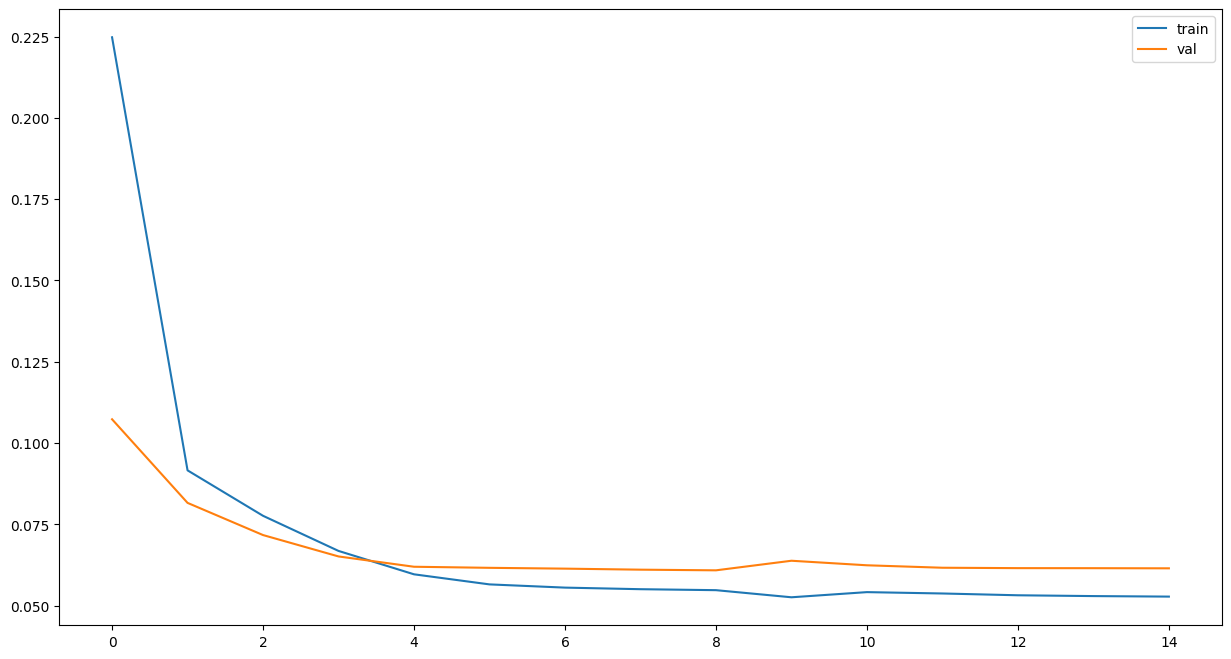

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(15, 8))

axs.plot(range(15), train_losses_m1, label="train")
axs.plot(range(15), val_losses_m1, label="val")
axs.legend()

In [ ]:
# Evaluación validation set
model1_4.eval()
all_preds_m1_4, all_labels_m1_4 = [], []
all_preds_m1_4_list, all_labels_m1_4_list = [], []
#embeddings_validation = []
with torch.no_grad():
    for window in val_windows:
        data = torch_geo_graphs_unsw1_proto_more_rnn[window].to(device)
        out,emb_v = model1_4(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m1_4.extend(preds)
        all_labels_m1_4.extend(data.y.cpu().numpy())
        all_preds_m1_4_list.append(preds)
        all_labels_m1_4_list.append(data.y.cpu().numpy())
        #embeddings_validation.append(emb_v)

# Metrics
roc_auc_m1_4 = roc_auc_score(all_labels_m1_4, all_preds_m1_4)
accuracy_m1_4 = accuracy_score(all_labels_m1_4, all_preds_m1_4)
precision_m1_4 = precision_score(all_labels_m1_4, all_preds_m1_4, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1_4 = recall_score(all_labels_m1_4, all_preds_m1_4, average='binary', zero_division=0)
f1_m1_4 = f1_score(all_labels_m1_4, all_preds_m1_4, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1_4:.4f}")
print(f"Accuracy: {accuracy_m1_4:.4f}")
print(f"Precision: {precision_m1_4:.4f}")
print(f"Recall: {recall_m1_4:.4f}")
print(f"F1: {f1_m1_4:.4f}")


ROC-AUC: 0.8090
Accuracy: 0.9726
Precision: 0.7155
Recall: 0.6296
F1: 0.6698


In [ ]:
model1_4.eval()
all_probabilities_m1_4_test, all_preds_m1_4_test, all_labels_m1_4_test = [], [], []
all_probabilities_m1_4_test_list = []
last_windows_for_test = [windows_input_test[i][-1] for i in range(len(windows_input_test))]

embeddings_test_m1_4 = []
with torch.no_grad():
    for window in range(len(last_windows_for_test)):
        data = last_windows_for_test[window].to(device)
        labels = last_windows_for_test[window].y
        out, emb_t = model1_4(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_probabilities_m1_4_test.extend(probabilities)
        all_probabilities_m1_4_test_list.append(probabilities)
        all_preds_m1_4_test.extend(preds)
        all_labels_m1_4_test.extend(labels.cpu().numpy())
        embeddings_test_m1_4.append(emb_t)

# Metrics
roc_auc_m1_4_test = roc_auc_score(all_labels_m1_4_test, all_preds_m1_4_test)
accuracy_m1_4_test = accuracy_score(all_labels_m1_4_test, all_preds_m1_4_test)
precision_m1_4_test = precision_score(all_labels_m1_4_test, all_preds_m1_4_test, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1_4_test = recall_score(all_labels_m1_4_test, all_preds_m1_4_test, average='binary', zero_division=0)
f1_m1_4_test = f1_score(all_labels_m1_4_test, all_preds_m1_4_test, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1_4_test:.4f}")
print(f"Accuracy: {accuracy_m1_4_test:.4f}")
print(f"Precision: {precision_m1_4_test:.4f}")
print(f"Recall: {recall_m1_4_test:.4f}")
print(f"F1: {f1_m1_4_test:.4f}")

ROC-AUC: 0.9054
Accuracy: 0.9709
Precision: 0.6593
Recall: 0.8329
F1: 0.7360


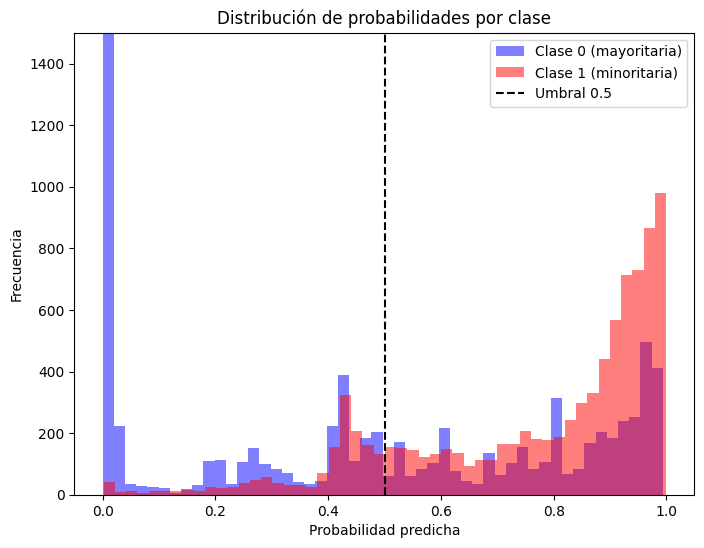

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(all_probabilities_m1_4_test)[np.array(all_labels_m1_4_test) == 0], bins=50, alpha=0.5, label="Clase 0 (mayoritaria)", color='blue')
plt.hist(np.array(all_probabilities_m1_4_test)[np.array(all_labels_m1_4_test) == 1], bins=50, alpha=0.5, label="Clase 1 (minoritaria)", color='red')
plt.axvline(0.5, color='black', linestyle='dashed', label='Umbral 0.5')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.ylim((0,1500))
plt.legend()
plt.title("Distribución de probabilidades por clase")
plt.show()

### Model 2_1: seq_len=4 - 25 windows for train, 5 for val

In [ ]:
#from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

model2_1 = EdgeClassificationModel_RNN(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16, hidden_size_gru=32, seq_len=4)
optimizer = torch.optim.Adam(model2_1.parameters(), lr=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 15
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)

# Train
epochs = 15
train_losses_m2 = []
val_losses_m2 = []

for epoch in range(epochs):
    # ===== Training for prediction in last snapshot =====
    model2_1.train()
    epoch_loss = 0
    total_edges = 0
    for window in range(len(windows_input_train)):
    #for window in train_windows:
        # data = ventanas_input[window] #.to(device)
        # labels = ventanas_target[window].y
        data_list = windows_input_train[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_train[window][-1].y

        optimizer.zero_grad()
        out = model2_1(data)
        mask = len(labels)
        valid_out = out[:mask]

        loss = loss_fn(valid_out.squeeze(), labels.to(device).float()) # convert to float

        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = labels.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges

    train_loss = epoch_loss / total_edges
    #train_loss = epoch_loss / len(windows_input_train)
    train_losses_m2.append(train_loss)

    # ===== Validation =====
    model2_1.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m2, all_labels_m2 = [], []
    with torch.no_grad():
        for window in range(len(windows_input_val)):
            data_list = windows_input_val[window]
            data = [tensor.to(device) for tensor in data_list]
            labels = windows_input_val[window][-1].y
            out = model2_1(data)
            mask = len(labels)
            valid_out = out[:mask]
            loss = loss_fn(valid_out.squeeze(), labels.to(device).float())
            probabilities = torch.sigmoid(valid_out)
            preds = (probabilities.view(-1) > 0.5).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = labels.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m2.extend(preds)
            all_labels_m2.extend(labels.cpu().numpy())
    val_loss_final = val_loss / total_val_edges
    val_losses_m2.append(val_loss_final)
    roc_auc_m2 = roc_auc_score(all_labels_m2, all_preds_m2)
    f1_m2 = f1_score(all_labels_m2, all_preds_m2, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m2)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m2}, F1:{f1_m2}")



Epoch 1/15, Train Loss: 0.2597, Val Loss: 0.1189, Current LR: 0.010000, ROC-AUC: 0.7147512624186052, F1:0.5316846986089645
Epoch 2/15, Train Loss: 0.0813, Val Loss: 0.0841, Current LR: 0.010000, ROC-AUC: 0.9490819419825505, F1:0.6783896344285053
Epoch 3/15, Train Loss: 0.0611, Val Loss: 0.0779, Current LR: 0.010000, ROC-AUC: 0.957786386792472, F1:0.6843792945487861
Epoch 4/15, Train Loss: 0.0566, Val Loss: 0.0747, Current LR: 0.010000, ROC-AUC: 0.9713141133019428, F1:0.6981818181818182
Epoch 5/15, Train Loss: 0.0577, Val Loss: 0.0749, Current LR: 0.010000, ROC-AUC: 0.9568127965693889, F1:0.6927374301675978
Epoch 6/15, Train Loss: 0.0546, Val Loss: 0.0766, Current LR: 0.010000, ROC-AUC: 0.974998324896905, F1:0.7001356852103121
Epoch 7/15, Train Loss: 0.0548, Val Loss: 0.0759, Current LR: 0.010000, ROC-AUC: 0.9666085964260407, F1:0.6915038618809632
Epoch 8/15, Train Loss: 0.0528, Val Loss: 0.0772, Current LR: 0.010000, ROC-AUC: 0.9698014444464749, F1:0.6944696282864914
Epoch 9/15, Train 

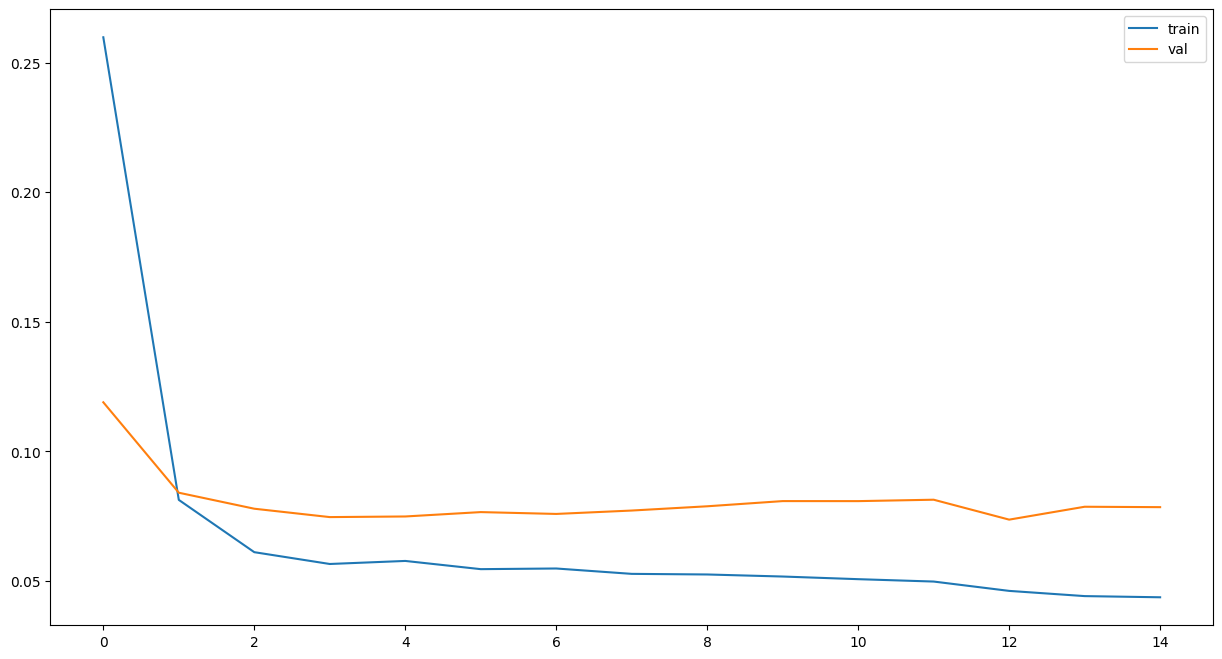

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(15, 8))

axs.plot(range(15), train_losses_m2, label="train")
axs.plot(range(15), val_losses_m2, label="val")
axs.legend()

In [ ]:
# Evaluación validation set
model2_1.eval()
all_preds_m2_1, all_labels_m2_1 = [], []
all_preds_m2_1_list, all_labels_m2_1_list = [], []
#embeddings_validation = []
with torch.no_grad():
    for window in range(len(windows_input_val)):
        data_list = windows_input_val[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_val[window][-1].y
        out = model2_1(data)
        mask = len(labels)
        valid_out = out[:mask]
        probabilities = torch.sigmoid(valid_out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m2_1.extend(preds)
        all_labels_m2_1.extend(labels.cpu().numpy())
        all_preds_m2_1_list.append(preds)
        all_labels_m2_1_list.append(labels.cpu().numpy())
        #embeddings_validation.append(emb_v)

# Metrics
roc_auc_m2_1 = roc_auc_score(all_labels_m2_1, all_preds_m2_1)
accuracy_m2_1 = accuracy_score(all_labels_m2_1, all_preds_m2_1)
precision_m2_1 = precision_score(all_labels_m2_1, all_preds_m2_1, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m2_1 = recall_score(all_labels_m2_1, all_preds_m2_1, average='binary', zero_division=0)
f1_m2_1 = f1_score(all_labels_m2_1, all_preds_m2_1, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m2_1:.4f}")
print(f"Accuracy: {accuracy_m2_1:.4f}")
print(f"Precision: {precision_m2_1:.4f}")
print(f"Recall: {recall_m2_1:.4f}")
print(f"F1: {f1_m2_1:.4f}")


ROC-AUC: 0.9665
Accuracy: 0.9651
Precision: 0.5602
Recall: 0.9681
F1: 0.7097


In [ ]:
model2_1.eval()
all_probabilities_m2_1_test, all_preds_m2_1_test, all_labels_m2_1_test = [], [], []
all_probabilities_m2_1_test_list = []
embeddings_test_m2_1 = []
with torch.no_grad():
    for window in range(len(windows_input_test)):
        data_list = windows_input_test[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_test[window][-1].y
        out = model2_1(data)
        mask = len(labels)
        valid_out = out[:mask]
        valid_emb = emb_t[:mask]
        probabilities = torch.sigmoid(valid_out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_probabilities_m2_1_test.extend(probabilities)
        all_probabilities_m2_1_test_list.append(probabilities)
        all_preds_m2_1_test.extend(preds)
        all_labels_m2_1_test.extend(labels.cpu().numpy())
        embeddings_test_m2_1.append(valid_emb)

# Metrics
roc_auc_m2_1_test = roc_auc_score(all_labels_m2_1_test, all_preds_m2_1_test)
accuracy_m2_1_test = accuracy_score(all_labels_m2_1_test, all_preds_m2_1_test)
precision_m2_1_test = precision_score(all_labels_m2_1_test, all_preds_m2_1_test, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m2_1_test = recall_score(all_labels_m2_1_test, all_preds_m2_1_test, average='binary', zero_division=0)
f1_m2_1_test = f1_score(all_labels_m2_1_test, all_preds_m2_1_test, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m2_1_test:.4f}")
print(f"Accuracy: {accuracy_m2_1_test:.4f}")
print(f"Precision: {precision_m2_1_test:.4f}")
print(f"Recall: {recall_m2_1_test:.4f}")
print(f"F1: {f1_m2_1_test:.4f}")

## Referencia de metricas de la GNN traditional:
# ROC-AUC: 0.9054
# Accuracy: 0.9709
# Precision: 0.6593
# Recall: 0.8329
# F1: 0.7360

ROC-AUC: 0.9608
Accuracy: 0.9755
Precision: 0.6782
Recall: 0.9446
F1: 0.7896


In [ ]:
all_probabilities_m1_4_test[:4]

[tensor([nan]), tensor([nan]), tensor([nan]), tensor([nan])]

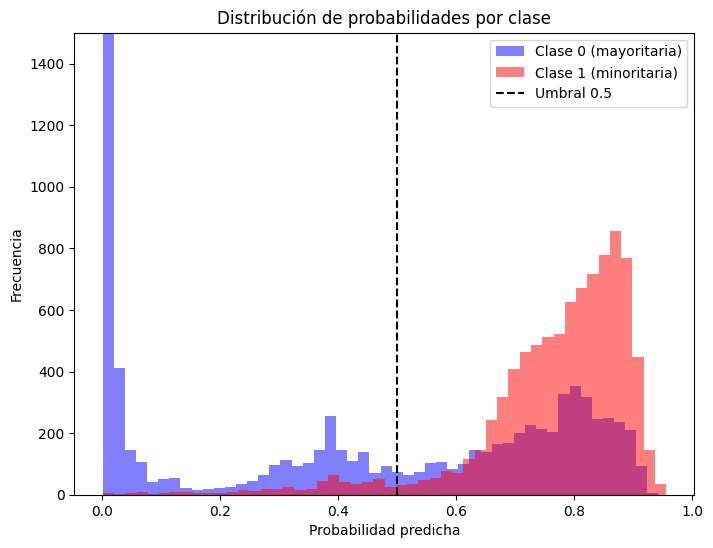

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(all_probabilities_m2_1_test)[np.array(all_labels_m2_1_test) == 0], bins=50, alpha=0.5, label="Clase 0 (mayoritaria)", color='blue')
plt.hist(np.array(all_probabilities_m2_1_test)[np.array(all_labels_m2_1_test) == 1], bins=50, alpha=0.5, label="Clase 1 (minoritaria)", color='red')
plt.axvline(0.5, color='black', linestyle='dashed', label='Umbral 0.5')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.ylim((0,1500))
plt.legend()
plt.title("Distribución de probabilidades por clase")
plt.show()

### Comparacion sobre test: seq_len=4

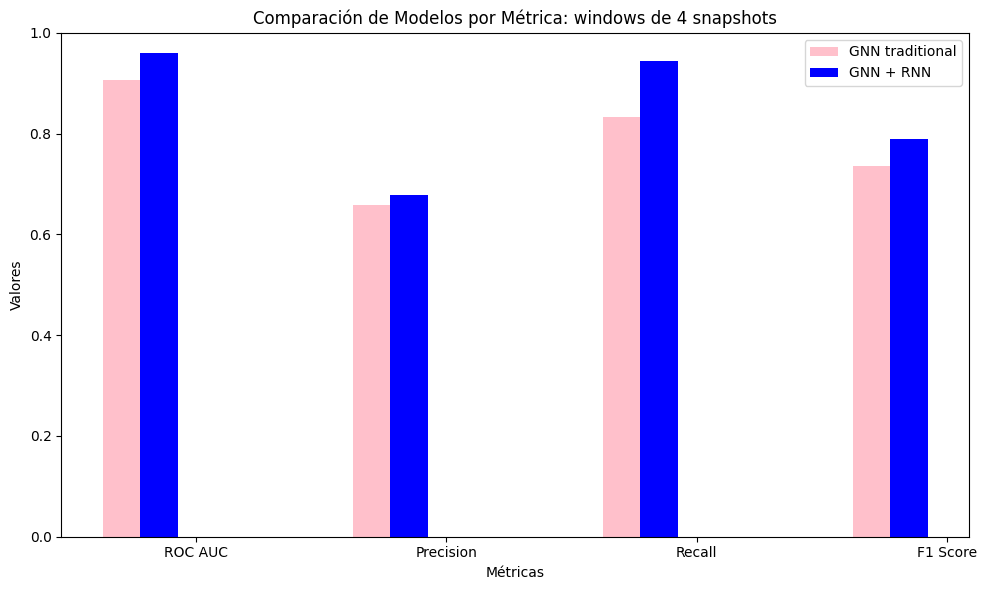

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Nombres de las métricas
#metric_names = ['ROC AUC', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
metric_names = ['ROC AUC', 'Precision', 'Recall', 'F1 Score']

# Nombres de los modelos
model_names = ['GNN traditional', 'GNN + RNN']

# Valores de las métricas para cada modelo
roc_auc = [roc_auc_m1_4_test, roc_auc_m2_1_test]
accuracy = [accuracy_m1_4_test, accuracy_m2_1_test]
precision = [precision_m1_4_test, precision_m2_1_test]
recall = [recall_m1_4_test, recall_m2_1_test]
f1 = [f1_m1_4_test, f1_m2_1_test]


# Lista de métricas agrupadas
#metrics = [roc_auc, accuracy, precision, recall, f1]
metrics = [roc_auc, precision, recall, f1]

# Colores para los modelos
colors = ['pink', 'blue']

# Crear el gráfico de barras agrupadas por métrica
x = np.arange(len(metric_names))  # Posiciones para las métricas
bar_width = 0.15  # Ancho de las barras

plt.figure(figsize=(10, 6))
for i, (model, color) in enumerate(zip(model_names, colors)):
    model_values = [metric[i] for metric in metrics]
    plt.bar(x + i * bar_width, model_values, width=bar_width, label=model, color=color)

# Personalización del gráfico
plt.xticks(x + 2 * bar_width, metric_names)
plt.xlabel('Métricas')
plt.ylabel('Valores')
plt.ylim((0,1))
plt.title('Comparación de Modelos por Métrica: windows de 4 snapshots')
plt.legend(loc='upper right')
plt.tight_layout()

# Mostrar el gráfico
plt.show()

## Windows of length 6 (25 windows for train, 1 for val)




### Model 1_4_1: traditional using same train set as model 2_3

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

model1_4_1 = GNN_traditional_normalize(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16).to(device)
optimizer = torch.optim.Adam(model1_4_1.parameters(), lr=0.01)
#scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 10
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
criterion = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)


train_windows2 = list(range(30))
val_windows2 = list(range(35,36)) # una sola captura para validar (la ultima)


# Train
epochs = 15
train_losses_m1 = []
val_losses_m1 = []

for epoch in range(epochs):
    # ===== Training =====
    model1_4_1.train()
    epoch_loss = 0
    total_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    for window in train_windows2:
        data = torch_geo_graphs_unsw1_proto_more_rnn[window].to(device)
        optimizer.zero_grad()
        out,_ = model1_4_1(data)
        loss = criterion(out.squeeze(), data.y.to(device).float()) # convert to float
        # probabilities = torch.sigmoid(out)
        # preds = (probabilities.view(-1) > 0.5).long()
        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = data.y.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges
        # all_preds_m1.extend(preds)
        # all_labels_m1.extend(data.y.cpu().numpy())
    #train_loss = epoch_loss / len(train_windows)
    train_loss = epoch_loss / total_edges
    train_losses_m1.append(train_loss)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # ===== Validation =====
    model1_4_1.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m1, all_labels_m1 = [], []
    with torch.no_grad():
        for window in val_windows2:
            data = torch_geo_graphs_unsw1_proto_more_rnn[window].to(device)
            out,_ = model1_4_1(data)
            loss = criterion(out.squeeze(), data.y.to(device).float())
            probabilities = torch.sigmoid(out)
            preds = (probabilities.view(-1) > 0.4).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = data.y.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m1.extend(preds)
            all_labels_m1.extend(data.y.cpu().numpy())
    val_loss_final = val_loss / total_val_edges #len(val_windows)
    val_losses_m1.append(val_loss_final)
    roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m1)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, , Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m1}, F1:{f1_m1}")



Epoch 1/15, Train Loss: 0.2228, Val Loss: 0.0701, , Current LR: 0.010000, ROC-AUC: 0.9762119416825512, F1:0.8958742632612967
Epoch 2/15, Train Loss: 0.0940, Val Loss: 0.0579, , Current LR: 0.010000, ROC-AUC: 0.9765158930503323, F1:0.8994082840236687
Epoch 3/15, Train Loss: 0.0786, Val Loss: 0.0510, , Current LR: 0.010000, ROC-AUC: 0.9809051568698162, F1:0.905511811023622
Epoch 4/15, Train Loss: 0.0701, Val Loss: 0.0479, , Current LR: 0.010000, ROC-AUC: 0.9598706918757406, F1:0.8853118712273642
Epoch 5/15, Train Loss: 0.0610, Val Loss: 0.0475, , Current LR: 0.010000, ROC-AUC: 0.9174978105198084, F1:0.8385744234800838
Epoch 6/15, Train Loss: 0.0561, Val Loss: 0.0491, , Current LR: 0.010000, ROC-AUC: 0.9026673020452322, F1:0.8212765957446808
Epoch 7/15, Train Loss: 0.0547, Val Loss: 0.0491, , Current LR: 0.010000, ROC-AUC: 0.9026673020452322, F1:0.8212765957446808
Epoch 8/15, Train Loss: 0.0539, Val Loss: 0.0485, , Current LR: 0.010000, ROC-AUC: 0.9005486579774354, F1:0.8187633262260128
E

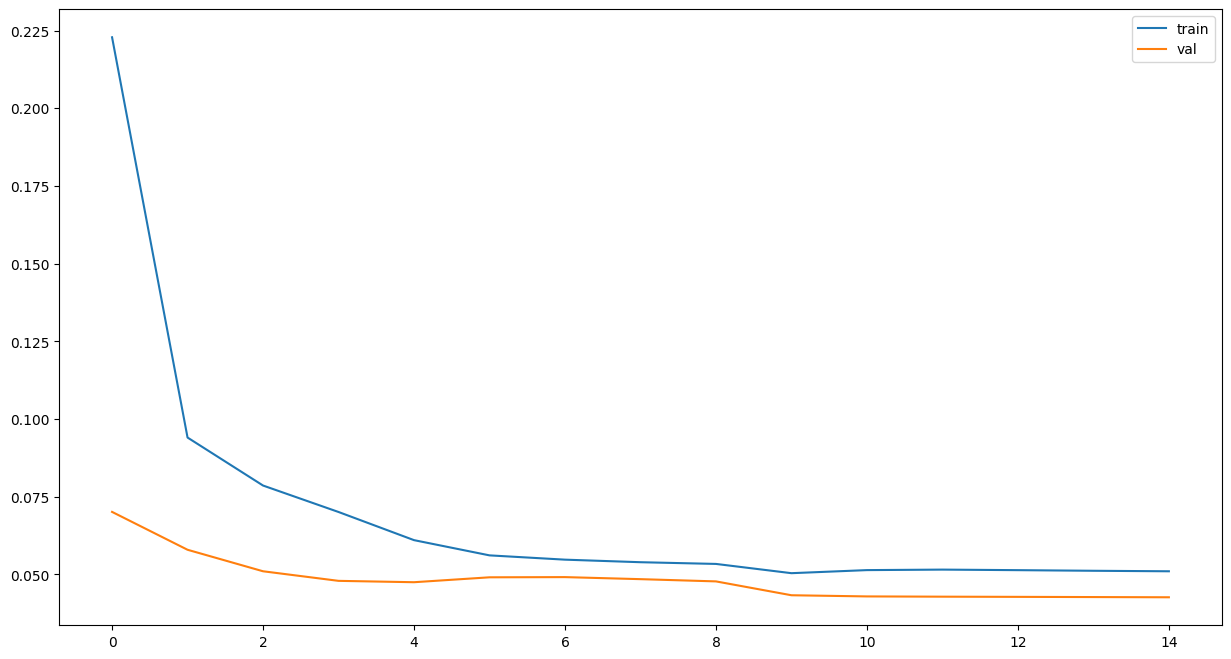

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(15, 8))

axs.plot(range(15), train_losses_m1, label="train")
axs.plot(range(15), val_losses_m1, label="val")
axs.legend()

In [ ]:
# Evaluación validation set
model1_4_1.eval()
all_preds_m1_4_1, all_labels_m1_4_1 = [], []
all_preds_m1_4_1_list, all_labels_m1_4_1_list = [], []
#embeddings_validation = []
with torch.no_grad():
    for window in val_windows2:
        data = torch_geo_graphs_unsw1_proto_more_rnn[window].to(device)
        out,emb_v = model1_4_1(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m1_4_1.extend(preds)
        all_labels_m1_4_1.extend(data.y.cpu().numpy())
        all_preds_m1_4_1_list.append(preds)
        all_labels_m1_4_1_list.append(data.y.cpu().numpy())
        #embeddings_validation.append(emb_v)

# Metrics
roc_auc_m1_4_1 = roc_auc_score(all_labels_m1_4_1, all_preds_m1_4_1)
accuracy_m1_4_1 = accuracy_score(all_labels_m1_4_1, all_preds_m1_4_1)
precision_m1_4_1 = precision_score(all_labels_m1_4_1, all_preds_m1_4_1, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1_4_1 = recall_score(all_labels_m1_4_1, all_preds_m1_4_1, average='binary', zero_division=0)
f1_m1_4_1 = f1_score(all_labels_m1_4_1, all_preds_m1_4_1, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1_4_1:.4f}")
print(f"Accuracy: {accuracy_m1_4_1:.4f}")
print(f"Precision: {precision_m1_4_1:.4f}")
print(f"Recall: {recall_m1_4_1:.4f}")
print(f"F1: {f1_m1_4_1:.4f}")



ROC-AUC: 0.9069
Accuracy: 0.9767
Precision: 0.8263
Recall: 0.8263
F1: 0.8263


In [ ]:
# Evaluación test
model1_4_1.eval()
all_probabilities_m1_4_1_test, all_preds_m1_4_1_test, all_labels_m1_4_1_test = [], [], []
all_probabilities_m1_4_1_test_list = []

last_windows_for_test2 = [windows_input_test2[i][-1] for i in range(len(windows_input_test2))]

#embeddings_validation = []
with torch.no_grad():
    for window in range(len(last_windows_for_test2)):
        data = last_windows_for_test2[window].to(device)
        labels = last_windows_for_test2[window].y
        out, emb_t = model1_4_1(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_probabilities_m1_4_1_test.extend(probabilities)
        all_probabilities_m1_4_1_test_list.append(probabilities)
        all_preds_m1_4_1_test.extend(preds)
        all_labels_m1_4_1_test.extend(labels.cpu().numpy())


# Metrics
roc_auc_m1_4_1_test = roc_auc_score(all_labels_m1_4_1_test, all_preds_m1_4_1_test)
accuracy_m1_4_1_test = accuracy_score(all_labels_m1_4_1_test, all_preds_m1_4_1_test)
precision_m1_4_1_test = precision_score(all_labels_m1_4_1_test, all_preds_m1_4_1_test, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1_4_1_test = recall_score(all_labels_m1_4_1_test, all_preds_m1_4_1_test, average='binary', zero_division=0)
f1_m1_4_1_test = f1_score(all_labels_m1_4_1_test, all_preds_m1_4_1_test, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1_4_1_test:.4f}")
print(f"Accuracy: {accuracy_m1_4_1_test:.4f}")
print(f"Precision: {precision_m1_4_1_test:.4f}")
print(f"Recall: {recall_m1_4_1_test:.4f}")
print(f"F1: {f1_m1_4_1_test:.4f}")

ROC-AUC: 0.9062
Accuracy: 0.9706
Precision: 0.6549
Recall: 0.8348
F1: 0.7340


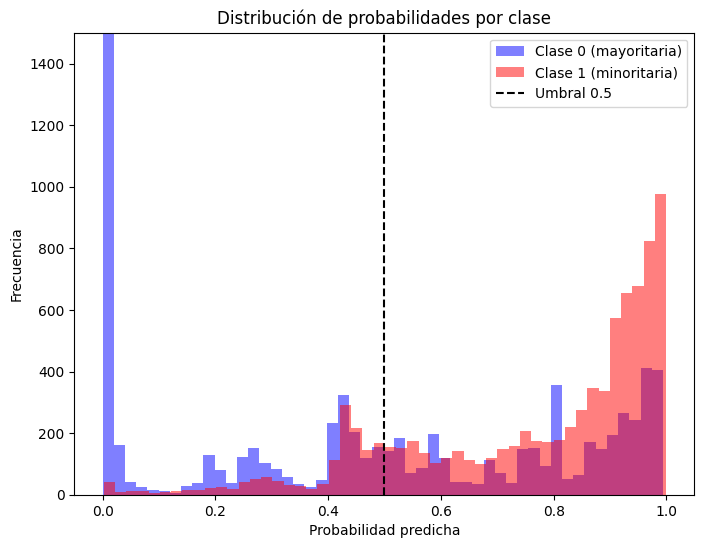

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(all_probabilities_m1_4_1_test)[np.array(all_labels_m1_4_1_test) == 0], bins=50, alpha=0.5, label="Clase 0 (mayoritaria)", color='blue')
plt.hist(np.array(all_probabilities_m1_4_1_test)[np.array(all_labels_m1_4_1_test) == 1], bins=50, alpha=0.5, label="Clase 1 (minoritaria)", color='red')
plt.axvline(0.5, color='black', linestyle='dashed', label='Umbral 0.5')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.ylim((0,1500))
plt.legend()
plt.title("Distribución de probabilidades por clase")
plt.show()

### Model 2_3: seq_len= 6 - 25 windows for train, 1 for val

In [ ]:
#from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

model2_3 = EdgeClassificationModel_RNN(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16, hidden_size_gru=32, seq_len=4)
optimizer = torch.optim.Adam(model2_3.parameters(), lr=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 15
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)

# Train
epochs = 15
train_losses_m2 = []
val_losses_m2 = []

for epoch in range(epochs):
    # ===== Training for prediction in last snapshot =====
    model2_3.train()
    epoch_loss = 0
    total_edges = 0
    for window in range(len(windows_input_train2)):
    #for window in train_windows:
        # data = ventanas_input[window] #.to(device)
        # labels = ventanas_target[window].y
        data_list = windows_input_train2[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_train2[window][-1].y

        optimizer.zero_grad()
        out = model2_3(data)
        mask = len(labels)
        valid_out = out[:mask]

        loss = loss_fn(valid_out.squeeze(), labels.to(device).float()) # convert to float

        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = labels.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges

    train_loss = epoch_loss / total_edges
    #train_loss = epoch_loss / len(windows_input_train)
    train_losses_m2.append(train_loss)

    # ===== Validation =====
    model2_3.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m2, all_labels_m2 = [], []
    with torch.no_grad():
        for window in range(len(windows_input_val2)):
            data_list = windows_input_val2[window]
            data = [tensor.to(device) for tensor in data_list]
            labels = windows_input_val2[window][-1].y
            out = model2_3(data)
            mask = len(labels)
            valid_out = out[:mask]
            loss = loss_fn(valid_out.squeeze(), labels.to(device).float())
            probabilities = torch.sigmoid(valid_out)
            preds = (probabilities.view(-1) > 0.5).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = labels.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m2.extend(preds)
            all_labels_m2.extend(labels.cpu().numpy())
    val_loss_final = val_loss / total_val_edges
    val_losses_m2.append(val_loss_final)
    roc_auc_m2 = roc_auc_score(all_labels_m2, all_preds_m2)
    f1_m2 = f1_score(all_labels_m2, all_preds_m2, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m2)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m2}, F1:{f1_m2}")



Epoch 1/15, Train Loss: 0.2439, Val Loss: 0.0763, Current LR: 0.010000, ROC-AUC: 0.9933130699088145, F1:0.9147286821705426
Epoch 2/15, Train Loss: 0.0794, Val Loss: 0.0427, Current LR: 0.010000, ROC-AUC: 0.9190175673587141, F1:0.8565310492505354
Epoch 3/15, Train Loss: 0.0596, Val Loss: 0.0401, Current LR: 0.010000, ROC-AUC: 0.966378599763021, F1:0.8937875751503006
Epoch 4/15, Train Loss: 0.0565, Val Loss: 0.0353, Current LR: 0.010000, ROC-AUC: 0.9916503528926898, F1:0.91796875
Epoch 5/15, Train Loss: 0.0543, Val Loss: 0.0355, Current LR: 0.010000, ROC-AUC: 0.9916503528926898, F1:0.91796875
Epoch 6/15, Train Loss: 0.0542, Val Loss: 0.0353, Current LR: 0.010000, ROC-AUC: 0.9916503528926898, F1:0.91796875
Epoch 7/15, Train Loss: 0.0526, Val Loss: 0.0347, Current LR: 0.010000, ROC-AUC: 0.9916503528926898, F1:0.91796875
Epoch 8/15, Train Loss: 0.0520, Val Loss: 0.0351, Current LR: 0.010000, ROC-AUC: 0.9916503528926898, F1:0.91796875
Epoch 9/15, Train Loss: 0.0513, Val Loss: 0.0348, Current

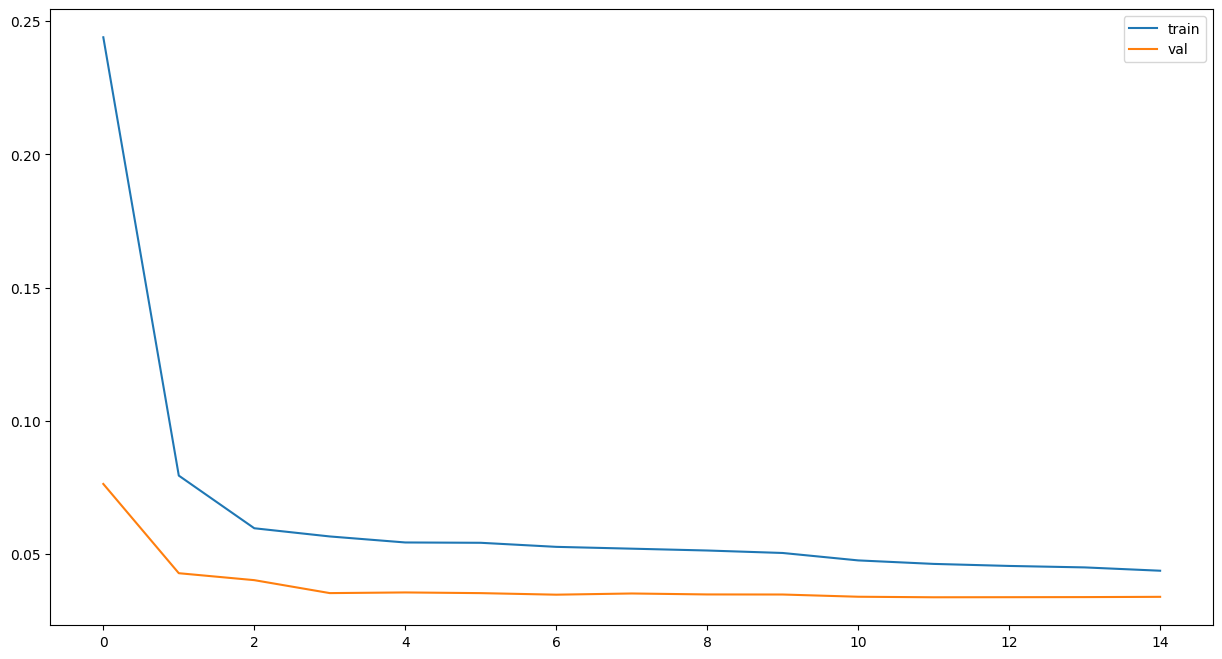

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(15, 8))

axs.plot(range(15), train_losses_m2, label="train")
axs.plot(range(15), val_losses_m2, label="val")
axs.legend()

In [ ]:
# Evaluación validation set
model2_3.eval()
all_preds_m2_3, all_labels_m2_3 = [], []
all_preds_m2_3_list, all_labels_m2_3_list = [], []
#embeddings_validation = []
with torch.no_grad():
    for window in range(len(windows_input_val2)):
        data_list = windows_input_val2[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_val2[window][-1].y
        out = model2_3(data)
        mask = len(labels)
        valid_out = out[:mask]
        probabilities = torch.sigmoid(valid_out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m2_3.extend(preds)
        all_labels_m2_3.extend(labels.cpu().numpy())
        all_preds_m2_3_list.append(preds)
        all_labels_m2_3_list.append(labels.cpu().numpy())
        #embeddings_validation.append(emb_v)

# Metrics
roc_auc_m2_3 = roc_auc_score(all_labels_m2_3, all_preds_m2_3)
accuracy_m2_3 = accuracy_score(all_labels_m2_3, all_preds_m2_3)
precision_m2_3 = precision_score(all_labels_m2_3, all_preds_m2_3, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m2_3 = recall_score(all_labels_m2_3, all_preds_m2_3, average='binary', zero_division=0)
f1_m2_3 = f1_score(all_labels_m2_3, all_preds_m2_3, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m2_3:.4f}")
print(f"Accuracy: {accuracy_m2_3:.4f}")
print(f"Precision: {precision_m2_3:.4f}")
print(f"Recall: {recall_m2_3:.4f}")
print(f"F1: {f1_m2_3:.4f}")


ROC-AUC: 0.9917
Accuracy: 0.9881
Precision: 0.8514
Recall: 0.9958
F1: 0.9180


In [ ]:
# Evaluación test
model2_3.eval()
all_probabilities_m2_3_test, all_preds_m2_3_test, all_labels_m2_3_test = [], [], []
all_probabilities_m2_3_test_list = []
#embeddings_validation = []
with torch.no_grad():
    for window in range(len(windows_input_test2)):
        data_list = windows_input_test2[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_test2[window][-1].y
        out = model2_3(data)
        mask = len(labels)
        valid_out = out[:mask]
        probabilities = torch.sigmoid(valid_out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_probabilities_m2_3_test.extend(probabilities)
        all_probabilities_m2_3_test_list.append(probabilities)
        all_preds_m2_3_test.extend(preds)
        all_labels_m2_3_test.extend(labels.cpu().numpy())


# Metrics
roc_auc_m2_3_test = roc_auc_score(all_labels_m2_3_test, all_preds_m2_3_test)
accuracy_m2_3_test = accuracy_score(all_labels_m2_3_test, all_preds_m2_3_test)
precision_m2_3_test = precision_score(all_labels_m2_3_test, all_preds_m2_3_test, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m2_3_test = recall_score(all_labels_m2_3_test, all_preds_m2_3_test, average='binary', zero_division=0)
f1_m2_3_test = f1_score(all_labels_m2_3_test, all_preds_m2_3_test, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m2_3_test:.4f}")
print(f"Accuracy: {accuracy_m2_3_test:.4f}")
print(f"Precision: {precision_m2_3_test:.4f}")
print(f"Recall: {recall_m2_3_test:.4f}")
print(f"F1: {f1_m2_3_test:.4f}")

## Referencia de metricas de la GNN traditional:
# ROC-AUC: 0.9062
# Accuracy: 0.9706
# Precision: 0.6549
# Recall: 0.8348
# F1: 0.7340

ROC-AUC: 0.9513
Accuracy: 0.9741
Precision: 0.6686
Recall: 0.9261
F1: 0.7766


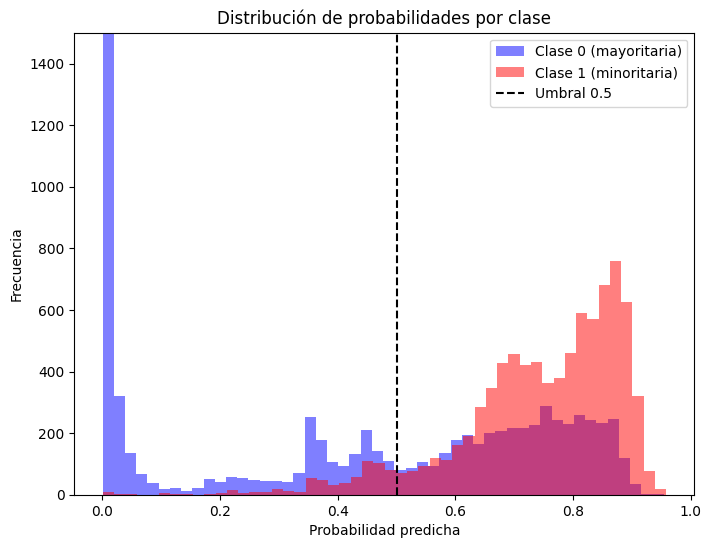

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(all_probabilities_m2_3_test)[np.array(all_labels_m2_3_test) == 0], bins=50, alpha=0.5, label="Clase 0 (mayoritaria)", color='blue')
plt.hist(np.array(all_probabilities_m2_3_test)[np.array(all_labels_m2_3_test) == 1], bins=50, alpha=0.5, label="Clase 1 (minoritaria)", color='red')
plt.axvline(0.5, color='black', linestyle='dashed', label='Umbral 0.5')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.ylim((0,1500))
plt.legend()
plt.title("Distribución de probabilidades por clase")
plt.show()

### Comparacion sobre test: seq_len=6 - 25 windows for train, 1 for val

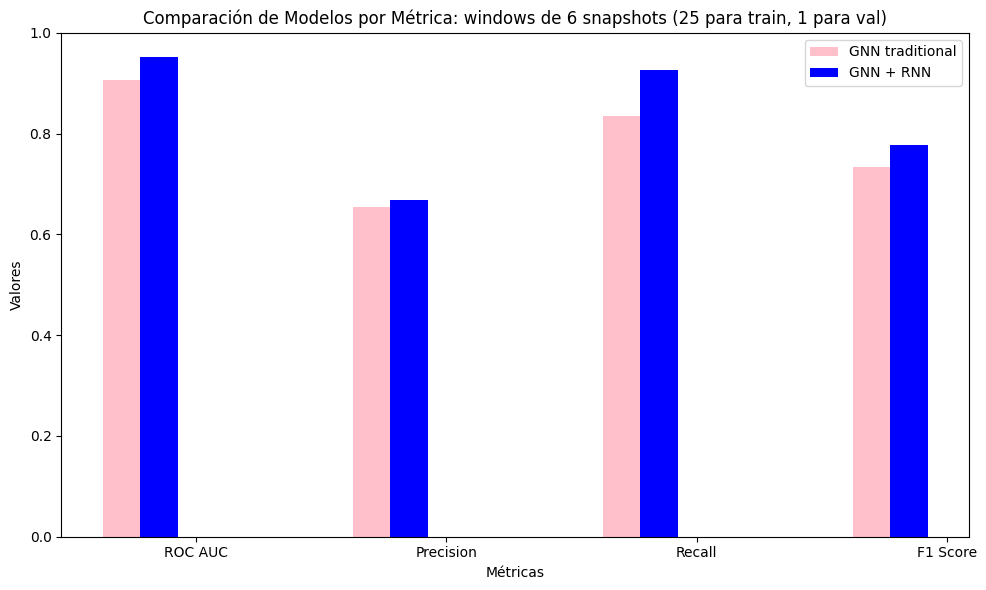

In [ ]:
# Nombres de las métricas
#metric_names = ['ROC AUC', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
metric_names = ['ROC AUC', 'Precision', 'Recall', 'F1 Score']

# Nombres de los modelos
model_names = ['GNN traditional', 'GNN + RNN']

# Valores de las métricas para cada modelo
roc_auc = [roc_auc_m1_4_1_test, roc_auc_m2_3_test]
accuracy = [accuracy_m1_4_1_test, accuracy_m2_3_test]
precision = [precision_m1_4_1_test, precision_m2_3_test]
recall = [recall_m1_4_1_test, recall_m2_3_test]
f1 = [f1_m1_4_1_test, f1_m2_3_test]


# Lista de métricas agrupadas
#metrics = [roc_auc, accuracy, precision, recall, f1]
metrics = [roc_auc, precision, recall, f1]

# Colores para los modelos
colors = ['pink', 'blue']#, 'green', 'orange']

# Crear el gráfico de barras agrupadas por métrica
x = np.arange(len(metric_names))  # Posiciones para las métricas
bar_width = 0.15  # Ancho de las barras

plt.figure(figsize=(10, 6))
for i, (model, color) in enumerate(zip(model_names, colors)):
    model_values = [metric[i] for metric in metrics]
    plt.bar(x + i * bar_width, model_values, width=bar_width, label=model, color=color)

# Personalización del gráfico
plt.xticks(x + 2 * bar_width, metric_names)
plt.xlabel('Métricas')
plt.ylabel('Valores')
plt.ylim((0,1))
plt.title('Comparación de Modelos por Métrica: windows de 6 snapshots (25 para train, 1 para val)')
plt.legend(loc='upper right')
plt.tight_layout()

# Mostrar el gráfico
plt.show()

## Windows of length 6 (21 windows for train, 5 for val)

### Model 1_4_2: traditional using same train set as model 2_4

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

model1_4_2 = GNN_traditional_normalize(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16).to(device)
optimizer = torch.optim.Adam(model1_4_2.parameters(), lr=0.01)
#scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 10
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
criterion = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)


train_windows3 = list(range(26))
val_windows3 = list(range(31,36))


# Train
epochs = 15
train_losses_m1 = []
val_losses_m1 = []

for epoch in range(epochs):
    # ===== Training =====
    model1_4_2.train()
    epoch_loss = 0
    total_edges = 0
    # all_preds_m1, all_labels_m1 = [], []
    for window in train_windows3:
        data = torch_geo_graphs_unsw1_proto_more_rnn[window].to(device)
        optimizer.zero_grad()
        out,_ = model1_4_2(data)
        loss = criterion(out.squeeze(), data.y.to(device).float()) # convert to float
        # probabilities = torch.sigmoid(out)
        # preds = (probabilities.view(-1) > 0.5).long()
        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = data.y.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges
        # all_preds_m1.extend(preds)
        # all_labels_m1.extend(data.y.cpu().numpy())
    #train_loss = epoch_loss / len(train_windows)
    train_loss = epoch_loss / total_edges
    train_losses_m1.append(train_loss)
    # roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    # f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # ===== Validation =====
    model1_4_2.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m1, all_labels_m1 = [], []
    with torch.no_grad():
        for window in val_windows3:
            data = torch_geo_graphs_unsw1_proto_more_rnn[window].to(device)
            out,_ = model1_4_2(data)
            loss = criterion(out.squeeze(), data.y.to(device).float())
            probabilities = torch.sigmoid(out)
            preds = (probabilities.view(-1) > 0.4).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = data.y.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m1.extend(preds)
            all_labels_m1.extend(data.y.cpu().numpy())
    val_loss_final = val_loss / total_val_edges #len(val_windows)
    val_losses_m1.append(val_loss_final)
    roc_auc_m1 = roc_auc_score(all_labels_m1, all_preds_m1)
    f1_m1 = f1_score(all_labels_m1, all_preds_m1, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m1)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, , Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m1}, F1:{f1_m1}")



Epoch 1/15, Train Loss: 0.2432, Val Loss: 0.1086, , Current LR: 0.010000, ROC-AUC: 0.9372953074778633, F1:0.6465556055830707
Epoch 2/15, Train Loss: 0.0967, Val Loss: 0.0830, , Current LR: 0.010000, ROC-AUC: 0.9232762173938645, F1:0.6333030027297544
Epoch 3/15, Train Loss: 0.0820, Val Loss: 0.0737, , Current LR: 0.010000, ROC-AUC: 0.9251563937162313, F1:0.6906906906906907
Epoch 4/15, Train Loss: 0.0724, Val Loss: 0.0686, , Current LR: 0.010000, ROC-AUC: 0.907075432430402, F1:0.7205720572057206
Epoch 5/15, Train Loss: 0.0641, Val Loss: 0.0638, , Current LR: 0.010000, ROC-AUC: 0.8455148860828374, F1:0.676829268292683
Epoch 6/15, Train Loss: 0.0600, Val Loss: 0.0617, , Current LR: 0.010000, ROC-AUC: 0.8262197288566457, F1:0.6582914572864321
Epoch 7/15, Train Loss: 0.0588, Val Loss: 0.0615, , Current LR: 0.010000, ROC-AUC: 0.8389616797324708, F1:0.6745195288282703
Epoch 8/15, Train Loss: 0.0585, Val Loss: 0.0622, , Current LR: 0.010000, ROC-AUC: 0.910444927686307, F1:0.7264722069345074
Epo

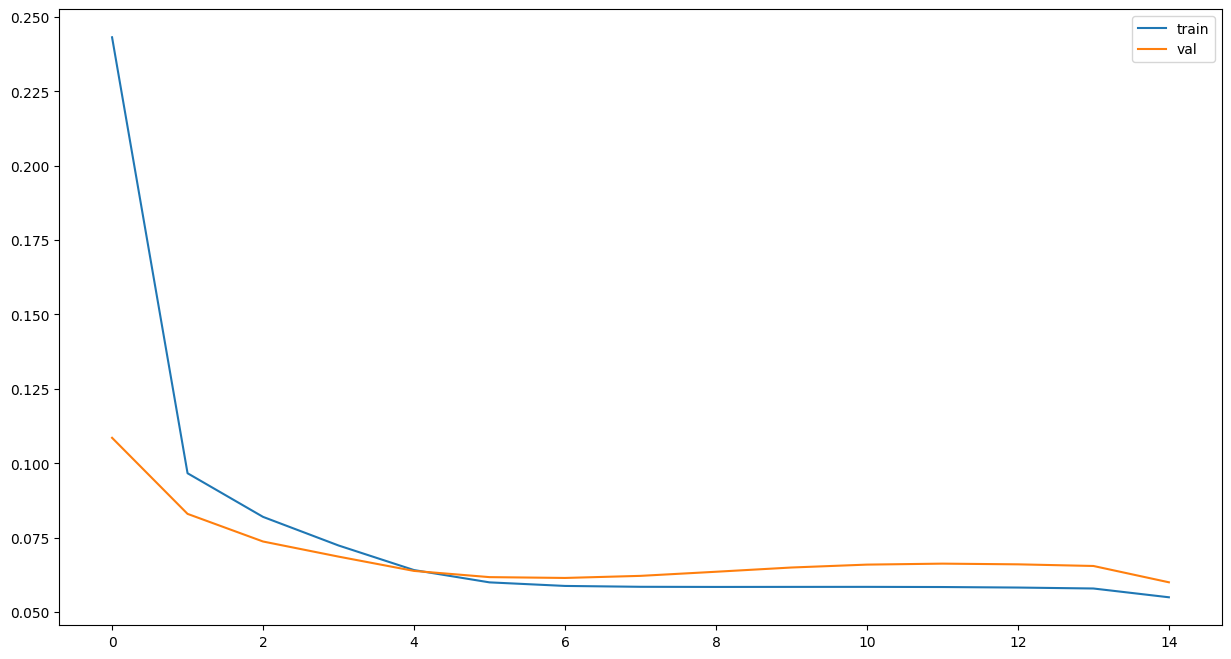

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(15, 8))

axs.plot(range(15), train_losses_m1, label="train")
axs.plot(range(15), val_losses_m1, label="val")
axs.legend()

In [ ]:
# Evaluación validation set
model1_4_2.eval()
all_preds_m1_4_2, all_labels_m1_4_2 = [], []
all_preds_m1_4_2_list, all_labels_m1_4_2_list = [], []
#embeddings_validation = []
with torch.no_grad():
    for window in val_windows3:
        data = torch_geo_graphs_unsw1_proto_more_rnn[window].to(device)
        out,emb_v = model1_4_2(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m1_4_2.extend(preds)
        all_labels_m1_4_2.extend(data.y.cpu().numpy())
        all_preds_m1_4_2_list.append(preds)
        all_labels_m1_4_2_list.append(data.y.cpu().numpy())
        #embeddings_validation.append(emb_v)

# Metrics
roc_auc_m1_4_2 = roc_auc_score(all_labels_m1_4_2, all_preds_m1_4_2)
accuracy_m1_4_2 = accuracy_score(all_labels_m1_4_2, all_preds_m1_4_2)
precision_m1_4_2 = precision_score(all_labels_m1_4_2, all_preds_m1_4_2, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1_4_2 = recall_score(all_labels_m1_4_2, all_preds_m1_4_2, average='binary', zero_division=0)
f1_m1_4_2 = f1_score(all_labels_m1_4_2, all_preds_m1_4_2, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1_4_2:.4f}")
print(f"Accuracy: {accuracy_m1_4_2:.4f}")
print(f"Precision: {precision_m1_4_2:.4f}")
print(f"Recall: {recall_m1_4_2:.4f}")
print(f"F1: {f1_m1_4_2:.4f}")


ROC-AUC: 0.7907
Accuracy: 0.9714
Precision: 0.7106
Recall: 0.5926
F1: 0.6462


In [ ]:
# Evaluación test
model1_4_2.eval()
all_probabilities_m1_4_2_test, all_preds_m1_4_2_test, all_labels_m1_4_2_test = [], [], []
all_probabilities_m1_4_2_test_list = []

last_windows_for_test2 = [windows_input_test2[i][-1] for i in range(len(windows_input_test2))]

#embeddings_validation = []
with torch.no_grad():
    for window in range(len(last_windows_for_test2)):
        data = last_windows_for_test2[window].to(device)
        labels = last_windows_for_test2[window].y
        out, emb_t = model1_4_2(data)
        probabilities = torch.sigmoid(out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_probabilities_m1_4_2_test.extend(probabilities)
        all_probabilities_m1_4_2_test_list.append(probabilities)
        all_preds_m1_4_2_test.extend(preds)
        all_labels_m1_4_2_test.extend(labels.cpu().numpy())
        #embeddings_validation.append(emb_v)

# Metrics
roc_auc_m1_4_2_test = roc_auc_score(all_labels_m1_4_2_test, all_preds_m1_4_2_test)
accuracy_m1_4_2_test = accuracy_score(all_labels_m1_4_2_test, all_preds_m1_4_2_test)
precision_m1_4_2_test = precision_score(all_labels_m1_4_2_test, all_preds_m1_4_2_test, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m1_4_2_test = recall_score(all_labels_m1_4_2_test, all_preds_m1_4_2_test, average='binary', zero_division=0)
f1_m1_4_2_test = f1_score(all_labels_m1_4_2_test, all_preds_m1_4_2_test, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m1_4_2_test:.4f}")
print(f"Accuracy: {accuracy_m1_4_2_test:.4f}")
print(f"Precision: {precision_m1_4_2_test:.4f}")
print(f"Recall: {recall_m1_4_2_test:.4f}")
print(f"F1: {f1_m1_4_2_test:.4f}")


ROC-AUC: 0.8781
Accuracy: 0.9701
Precision: 0.6644
Recall: 0.7762
F1: 0.7159


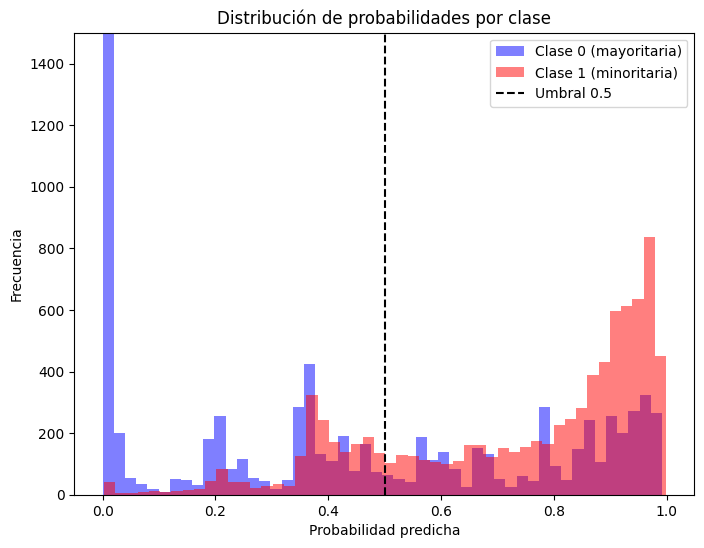

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(all_probabilities_m1_4_2_test)[np.array(all_labels_m1_4_2_test) == 0], bins=50, alpha=0.5, label="Clase 0 (mayoritaria)", color='blue')
plt.hist(np.array(all_probabilities_m1_4_2_test)[np.array(all_labels_m1_4_2_test) == 1], bins=50, alpha=0.5, label="Clase 1 (minoritaria)", color='red')
plt.axvline(0.5, color='black', linestyle='dashed', label='Umbral 0.5')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.ylim((0,1500))
plt.legend()
plt.title("Distribución de probabilidades por clase")
plt.show()

### Model 2_4: seq_len=6 - 21 windows for train, 5 for val

In [ ]:
#from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

model2_4 = EdgeClassificationModel_RNN(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16, hidden_size_gru=32, seq_len=4)
optimizer = torch.optim.Adam(model2_4.parameters(), lr=0.01)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


#ratio_neg_to_pos = 15
#pos_weight = torch.tensor([ratio_neg_to_pos], dtype=torch.float32).to(device)
loss_fn = torch.nn.BCEWithLogitsLoss()#pos_weight=pos_weight)

# Train
epochs = 15
train_losses_m2 = []
val_losses_m2 = []

for epoch in range(epochs):
    # ===== Training for prediction in last snapshot =====
    model2_4.train()
    epoch_loss = 0
    total_edges = 0
    for window in range(len(windows_input_train3)):
    #for window in train_windows:
        # data = ventanas_input[window] #.to(device)
        # labels = ventanas_target[window].y
        data_list = windows_input_train3[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_train3[window][-1].y

        optimizer.zero_grad()
        out = model2_4(data)
        mask = len(labels)
        valid_out = out[:mask]

        loss = loss_fn(valid_out.squeeze(), labels.to(device).float()) # convert to float

        loss.backward()
        optimizer.step()
        # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
        #epoch_loss += loss.item()
        num_edges = labels.size(0)
        epoch_loss += loss.item() * num_edges
        total_edges += num_edges

    train_loss = epoch_loss / total_edges
    #train_loss = epoch_loss / len(windows_input_train)
    train_losses_m2.append(train_loss)

    # ===== Validation =====
    model2_4.eval()
    val_loss = 0
    total_val_edges = 0
    all_preds_m2, all_labels_m2 = [], []
    with torch.no_grad():
        for window in range(len(windows_input_val3)):
            data_list = windows_input_val3[window]
            data = [tensor.to(device) for tensor in data_list]
            labels = windows_input_val3[window][-1].y
            out = model2_4(data)
            mask = len(labels)
            valid_out = out[:mask]
            loss = loss_fn(valid_out.squeeze(), labels.to(device).float())
            probabilities = torch.sigmoid(valid_out)
            preds = (probabilities.view(-1) > 0.5).long()
            # CAMBIO PARA ESCALAR POR EL NUMERO DE ARISTAS
            num_edges = labels.size(0)
            val_loss += loss.item() * num_edges
            total_val_edges += num_edges
            all_preds_m2.extend(preds)
            all_labels_m2.extend(labels.cpu().numpy())
    val_loss_final = val_loss / total_val_edges
    val_losses_m2.append(val_loss_final)
    roc_auc_m2 = roc_auc_score(all_labels_m2, all_preds_m2)
    f1_m2 = f1_score(all_labels_m2, all_preds_m2, average='binary', zero_division=0)

    # Actualizar el scheduler
    scheduler.step(f1_m2)

    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss_final:.4f}, Current LR: {optimizer.param_groups[0]['lr']:.6f}, ROC-AUC: {roc_auc_m2}, F1:{f1_m2}")



Epoch 1/15, Train Loss: 0.2722, Val Loss: 0.1826, Current LR: 0.010000, ROC-AUC: 0.5, F1:0.0
Epoch 2/15, Train Loss: 0.1325, Val Loss: 0.0980, Current LR: 0.010000, ROC-AUC: 0.8637755402461285, F1:0.5425389755011136
Epoch 3/15, Train Loss: 0.0732, Val Loss: 0.0801, Current LR: 0.010000, ROC-AUC: 0.9283604090906323, F1:0.6806640625
Epoch 4/15, Train Loss: 0.0665, Val Loss: 0.0737, Current LR: 0.010000, ROC-AUC: 0.9357471061325016, F1:0.6986166007905138
Epoch 5/15, Train Loss: 0.0603, Val Loss: 0.0713, Current LR: 0.010000, ROC-AUC: 0.929341105811694, F1:0.6987951807228916
Epoch 6/15, Train Loss: 0.0600, Val Loss: 0.0718, Current LR: 0.010000, ROC-AUC: 0.9462697992109758, F1:0.6987951807228916
Epoch 7/15, Train Loss: 0.0590, Val Loss: 0.0718, Current LR: 0.010000, ROC-AUC: 0.9430860881165142, F1:0.7024914509037616
Epoch 8/15, Train Loss: 0.0580, Val Loss: 0.0720, Current LR: 0.010000, ROC-AUC: 0.94689923188909, F1:0.6927108146736541
Epoch 9/15, Train Loss: 0.0580, Val Loss: 0.0728, Curre

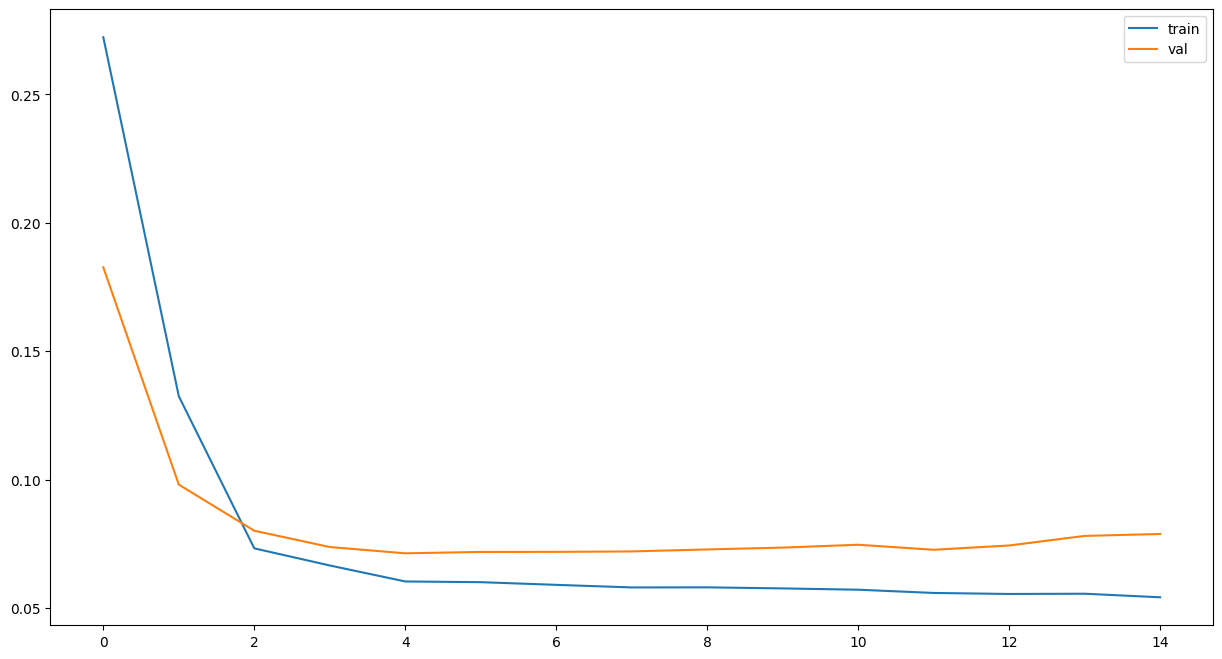

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(figsize=(15, 8))

axs.plot(range(15), train_losses_m2, label="train")
axs.plot(range(15), val_losses_m2, label="val")
axs.legend()

In [ ]:
# Evaluación validation set
model2_4.eval()
all_preds_m2_4, all_labels_m2_4 = [], []
all_preds_m2_4_list, all_labels_m2_4_list = [], []
#embeddings_validation = []
with torch.no_grad():
    for window in range(len(windows_input_val3)):
        data_list = windows_input_val3[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_val3[window][-1].y
        out = model2_4(data)
        mask = len(labels)
        valid_out = out[:mask]
        probabilities = torch.sigmoid(valid_out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_preds_m2_4.extend(preds)
        all_labels_m2_4.extend(labels.cpu().numpy())
        all_preds_m2_4_list.append(preds)
        all_labels_m2_4_list.append(labels.cpu().numpy())
        #embeddings_validation.append(emb_v)

# Metrics
roc_auc_m2_4 = roc_auc_score(all_labels_m2_4, all_preds_m2_4)
accuracy_m2_4 = accuracy_score(all_labels_m2_4, all_preds_m2_4)
precision_m2_4 = precision_score(all_labels_m2_4, all_preds_m2_4, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m2_4 = recall_score(all_labels_m2_4, all_preds_m2_4, average='binary', zero_division=0)
f1_m2_4 = f1_score(all_labels_m2_4, all_preds_m2_4, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m2_4:.4f}")
print(f"Accuracy: {accuracy_m2_4:.4f}")
print(f"Precision: {precision_m2_4:.4f}")
print(f"Recall: {recall_m2_4:.4f}")
print(f"F1: {f1_m2_4:.4f}")


ROC-AUC: 0.9628
Accuracy: 0.9638
Precision: 0.5508
Recall: 0.9617
F1: 0.7005


In [ ]:
# Evaluación test
model2_4.eval()

all_probabilities_m2_4_test, all_preds_m2_4_test, all_labels_m2_4_test = [], [], []
all_probabilities_m2_4_test_list = []
#embeddings_validation = []
with torch.no_grad():
    for window in range(len(windows_input_test2)):
        data_list = windows_input_test2[window]
        data = [tensor.to(device) for tensor in data_list]
        labels = windows_input_test2[window][-1].y
        out = model2_4(data)
        mask = len(labels)
        valid_out = out[:mask]
        probabilities = torch.sigmoid(valid_out)  # Apply sigmoid to get probabilities
        # Convert probabilities to binary predictions using a threshold
        preds = (probabilities.view(-1) > 0.5).long()  # Thresholding at 0.5

        all_probabilities_m2_4_test.extend(probabilities)
        all_probabilities_m2_4_test_list.append(probabilities)
        all_preds_m2_4_test.extend(preds)
        all_labels_m2_4_test.extend(labels.cpu().numpy())


# Metrics
roc_auc_m2_4_test = roc_auc_score(all_labels_m2_4_test, all_preds_m2_4_test)
accuracy_m2_4_test = accuracy_score(all_labels_m2_4_test, all_preds_m2_4_test)
precision_m2_4_test = precision_score(all_labels_m2_4_test, all_preds_m2_4_test, average='binary', zero_division=0)  # Use 'binary' for binary classification
recall_m2_4_test = recall_score(all_labels_m2_4_test, all_preds_m2_4_test, average='binary', zero_division=0)
f1_m2_4_test = f1_score(all_labels_m2_4_test, all_preds_m2_4_test, average='binary', zero_division=0)

print(f"ROC-AUC: {roc_auc_m2_4_test:.4f}")
print(f"Accuracy: {accuracy_m2_4_test:.4f}")
print(f"Precision: {precision_m2_4_test:.4f}")
print(f"Recall: {recall_m2_4_test:.4f}")
print(f"F1: {f1_m2_4_test:.4f}")

## Referencia de metricas de la GNN traditional:
# ROC-AUC: 0.8781
# Accuracy: 0.9701
# Precision: 0.6644
# Recall: 0.7762
# F1: 0.7159

ROC-AUC: 0.9470
Accuracy: 0.9706
Precision: 0.6364
Recall: 0.9208
F1: 0.7526


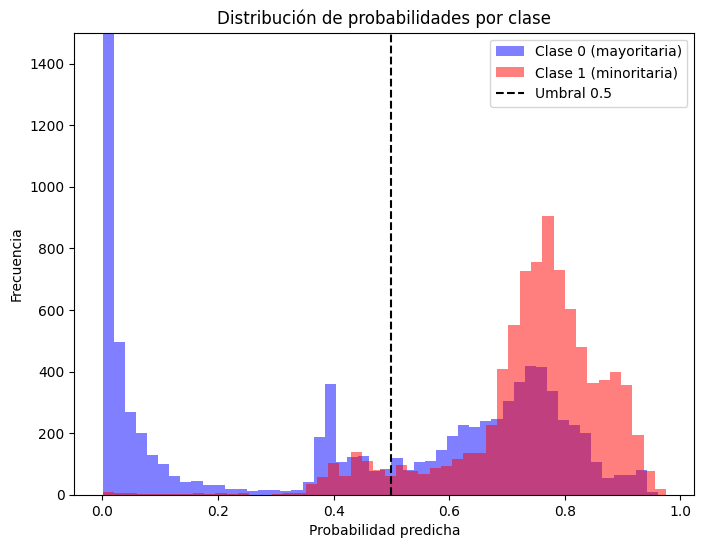

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(np.array(all_probabilities_m2_4_test)[np.array(all_labels_m2_4_test) == 0], bins=50, alpha=0.5, label="Clase 0 (mayoritaria)", color='blue')
plt.hist(np.array(all_probabilities_m2_4_test)[np.array(all_labels_m2_4_test) == 1], bins=50, alpha=0.5, label="Clase 1 (minoritaria)", color='red')
plt.axvline(0.5, color='black', linestyle='dashed', label='Umbral 0.5')
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")
plt.ylim((0,1500))
plt.legend()
plt.title("Distribución de probabilidades por clase")
plt.show()

### Comparacion sobre test: seq_len=6 - 21 windows for train, 5 for val

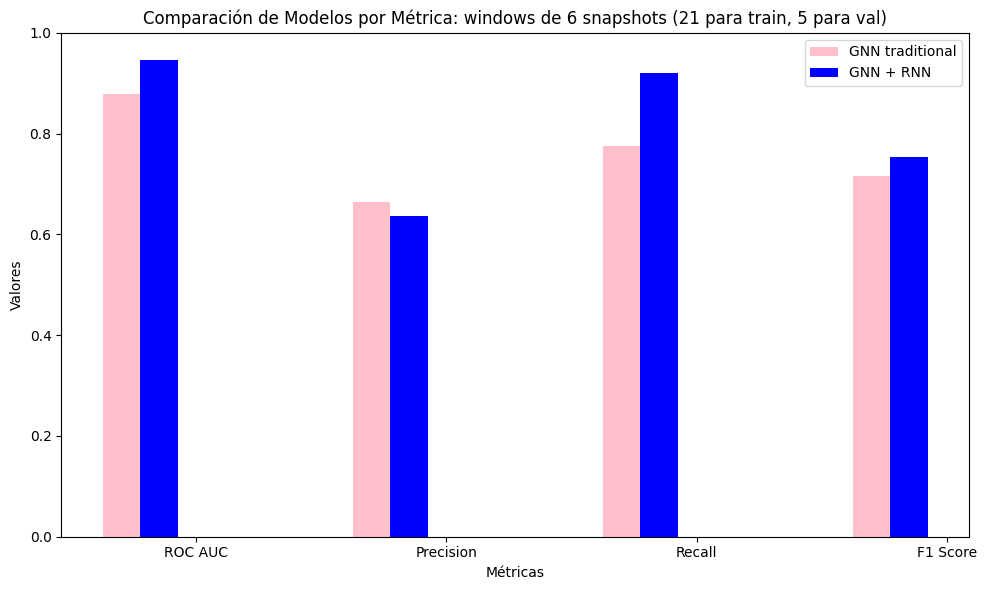

In [ ]:
# Nombres de las métricas
#metric_names = ['ROC AUC', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
metric_names = ['ROC AUC', 'Precision', 'Recall', 'F1 Score']

# Nombres de los modelos
model_names = ['GNN traditional', 'GNN + RNN']

# Valores de las métricas para cada modelo
roc_auc = [roc_auc_m1_4_2_test, roc_auc_m2_4_test]
accuracy = [accuracy_m1_4_2_test, accuracy_m2_4_test]
precision = [precision_m1_4_2_test, precision_m2_4_test]
recall = [recall_m1_4_2_test, recall_m2_4_test]
f1 = [f1_m1_4_2_test, f1_m2_4_test]


# Lista de métricas agrupadas
#metrics = [roc_auc, accuracy, precision, recall, f1]
metrics = [roc_auc, precision, recall, f1]

# Colores para los modelos
colors = ['pink', 'blue']

# Crear el gráfico de barras agrupadas por métrica
x = np.arange(len(metric_names))  # Posiciones para las métricas
bar_width = 0.15  # Ancho de las barras

plt.figure(figsize=(10, 6))
for i, (model, color) in enumerate(zip(model_names, colors)):
    model_values = [metric[i] for metric in metrics]
    plt.bar(x + i * bar_width, model_values, width=bar_width, label=model, color=color)

# Personalización del gráfico
plt.xticks(x + 2 * bar_width, metric_names)
plt.xlabel('Métricas')
plt.ylabel('Valores')
plt.ylim((0,1))
plt.title('Comparación de Modelos por Métrica: windows de 6 snapshots (21 para train, 5 para val)')
plt.legend(loc='upper right')
plt.tight_layout()

# Mostrar el gráfico
plt.show()

## Comparaciones

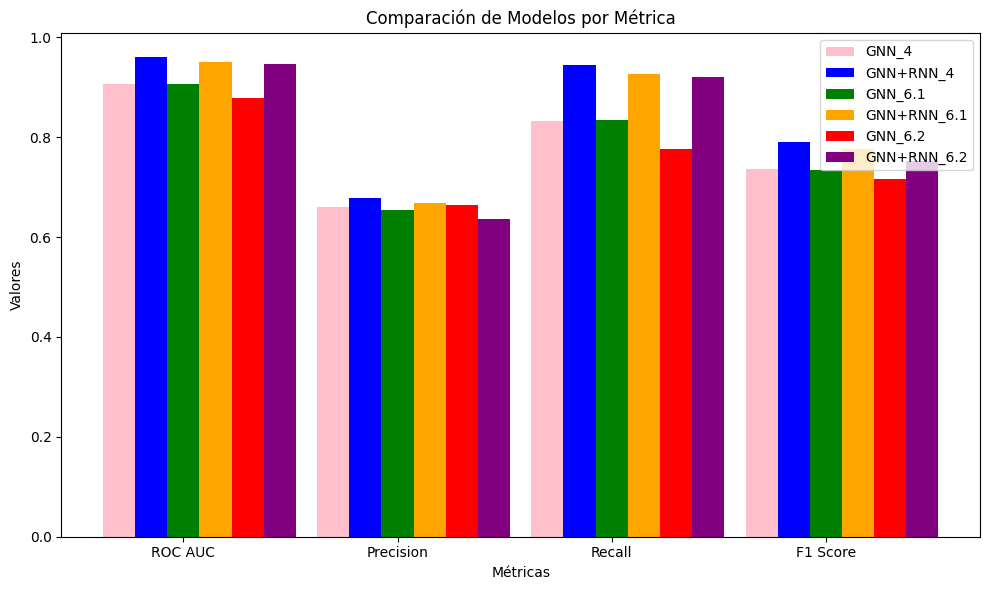

In [ ]:
# Nombres de las métricas
#metric_names = ['ROC AUC', 'Accuracy', 'Precision', 'Recall', 'F1 Score']
metric_names = ['ROC AUC', 'Precision', 'Recall', 'F1 Score']

# Nombres de los modelos
model_names = ['GNN_4', 'GNN+RNN_4', 'GNN_6.1', 'GNN+RNN_6.1', 'GNN_6.2', 'GNN+RNN_6.2']

# Valores de las métricas para cada modelo
roc_auc = [roc_auc_m1_4_test, roc_auc_m2_1_test, roc_auc_m1_4_1_test, roc_auc_m2_3_test, roc_auc_m1_4_2_test, roc_auc_m2_4_test]
accuracy = [accuracy_m1_4_test, accuracy_m2_1_test, accuracy_m1_4_1_test, accuracy_m2_3_test, accuracy_m1_4_2_test, accuracy_m2_4_test]
precision = [precision_m1_4_test, precision_m2_1_test, precision_m1_4_1_test, precision_m2_3_test, precision_m1_4_2_test, precision_m2_4_test]
recall = [recall_m1_4_test, recall_m2_1_test, recall_m1_4_1_test, recall_m2_3_test, recall_m1_4_2_test, recall_m2_4_test]
f1 = [f1_m1_4_test, f1_m2_1_test, f1_m1_4_1_test, f1_m2_3_test, f1_m1_4_2_test, f1_m2_4_test]


# Lista de métricas agrupadas
#metrics = [roc_auc, accuracy, precision, recall, f1]
metrics = [roc_auc, precision, recall, f1]

# Colores para los modelos
colors = ['pink', 'blue', 'green', 'orange', 'red', 'purple']

# Crear el gráfico de barras agrupadas por métrica
x = np.arange(len(metric_names))  # Posiciones para las métricas
bar_width = 0.15  # Ancho de las barras

plt.figure(figsize=(10, 6))
for i, (model, color) in enumerate(zip(model_names, colors)):
    model_values = [metric[i] for metric in metrics]
    plt.bar(x + i * bar_width, model_values, width=bar_width, label=model, color=color)

# Personalización del gráfico
plt.xticks(x + 2 * bar_width, metric_names)
plt.xlabel('Métricas')
plt.ylabel('Valores')
plt.title('Comparación de Modelos por Métrica')
plt.legend(loc='upper right')
plt.tight_layout()

# Mostrar el gráfico
plt.show()

# Repeticiones

## GNN traditional

In [ ]:
import torch
import numpy as np
import random
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from torch.optim.lr_scheduler import ReduceLROnPlateau

def train_and_evaluate_model(seed, model_class, dataset_train, dataset_val, dataset_test, device, epochs=15):
    # === Set seed for reproducibility ===
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # === Initialize model, optimizer, loss, scheduler ===
    model = model_class(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
    criterion = torch.nn.BCEWithLogitsLoss()

    # === Training ===
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        total_edges = 0

        for window in dataset_train:
            data = window.to(device)
            optimizer.zero_grad()
            out, _ = model(data)
            loss = criterion(out.squeeze(), data.y.to(device).float())
            num_edges = data.y.size(0)
            total_train_loss += loss.item() * num_edges
            total_edges += num_edges
            loss.backward()
            optimizer.step()

        train_loss = total_train_loss / total_edges

        # === Validation ===
        model.eval()
        total_val_loss = 0
        total_val_edges = 0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for window in dataset_val:
                data = window.to(device)
                out, _ = model(data)
                loss = criterion(out.squeeze(), data.y.to(device).float())
                probs = torch.sigmoid(out)
                preds = (probs.view(-1) > 0.4).long()
                num_edges = data.y.size(0)
                total_val_loss += loss.item() * num_edges
                total_val_edges += num_edges
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(data.y.cpu().numpy())

        val_loss = total_val_loss / total_val_edges
        f1 = f1_score(all_labels, all_preds, zero_division=0)
        scheduler.step(f1)

    # === Final test ===
    model.eval()
    all_preds_test, all_labels_test = [], []
    with torch.no_grad():
        for data in dataset_test:
            data = data.to(device)
            out, _ = model(data)
            probs = torch.sigmoid(out)
            preds = (probs.view(-1) > 0.5).long()
            all_preds_test.extend(preds.cpu().numpy())
            all_labels_test.extend(data.y.cpu().numpy())

    # === Metrics ===
    roc_auc = roc_auc_score(all_labels_test, all_preds_test)
    acc = accuracy_score(all_labels_test, all_preds_test)
    prec = precision_score(all_labels_test, all_preds_test, zero_division=0)
    rec = recall_score(all_labels_test, all_preds_test, zero_division=0)
    f1 = f1_score(all_labels_test, all_preds_test, zero_division=0)

    # === FPR ===
    tn, fp, fn, tp = confusion_matrix(all_labels_test, all_preds_test).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    return roc_auc, acc, prec, rec, f1, fpr


In [ ]:
n_runs = 10
results_gnn = {'roc_auc': [], 'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'fpr': []}

for i in range(n_runs):
    print(f"🔁 Run {i+1}/{n_runs}")
    roc_auc, acc, prec, rec, f1, fpr = train_and_evaluate_model(
        seed=i,
        model_class=GNN_traditional_normalize,
        dataset_train=[torch_geo_graphs_unsw1_proto_more_rnn[w] for w in range(28)],
        dataset_val=[torch_geo_graphs_unsw1_proto_more_rnn[w] for w in range(31, 36)],
        dataset_test=[windows_input_test[j][-1] for j in range(len(windows_input_test))],
        device=device,
        epochs=15
    )
    results_gnn['roc_auc'].append(roc_auc)
    results_gnn['accuracy'].append(acc)
    results_gnn['precision'].append(prec)
    results_gnn['recall'].append(rec)
    results_gnn['f1'].append(f1)
    results_gnn['fpr'].append(fpr)



df_gnn = pd.DataFrame(results_gnn)
df_gnn.to_csv('resultados_gnn.csv', index=False)


🔁 Run 1/10
🔁 Run 2/10
🔁 Run 3/10
🔁 Run 4/10
🔁 Run 5/10
🔁 Run 6/10
🔁 Run 7/10
🔁 Run 8/10
🔁 Run 9/10
🔁 Run 10/10


In [ ]:
print("\n=== Resultados Promedio ± Desviación Estándar ===")
for metric in results_gnn:
    mean = np.mean(results_gnn[metric])
    std = np.std(results_gnn[metric])
    print(f"{metric.upper():>10}: {mean:.4f} ± {std:.4f}")



=== Resultados Promedio ± Desviación Estándar ===
   ROC_AUC: 0.9071 ± 0.0050
  ACCURACY: 0.9710 ± 0.0003
 PRECISION: 0.6592 ± 0.0013
    RECALL: 0.8363 ± 0.0102
        F1: 0.7372 ± 0.0040
       FPR: 0.0221 ± 0.0003


## GNN + RNN

In [ ]:
def train_and_evaluate_model_rnn(seed, model_class, windows_input_train, windows_input_val, windows_input_test, device, epochs=15):
    import torch
    import numpy as np
    import random
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

    # === Set seeds for reproducibility ===
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # === Model and optimizer ===
    model = model_class(node_input_dim=14, edge_input_dim=3, hidden_dim1=32, hidden_dim2=16, hidden_size_gru=32, seq_len=4).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
    loss_fn = torch.nn.BCEWithLogitsLoss()

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        total_edges = 0

        for window in range(len(windows_input_train)):
            data_list = windows_input_train[window]
            data = [d.to(device) for d in data_list]
            labels = data_list[-1].y

            optimizer.zero_grad()
            out = model(data)
            mask = len(labels)
            valid_out = out[:mask]
            loss = loss_fn(valid_out.squeeze(), labels.to(device).float())
            loss.backward()
            optimizer.step()

            num_edges = labels.size(0)
            epoch_loss += loss.item() * num_edges
            total_edges += num_edges

        train_loss = epoch_loss / total_edges

        # === Validation ===
        model.eval()
        val_loss = 0
        total_val_edges = 0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for window in range(len(windows_input_val)):
                data_list = windows_input_val[window]
                data = [d.to(device) for d in data_list]
                labels = data_list[-1].y
                out = model(data)
                mask = len(labels)
                valid_out = out[:mask]
                loss = loss_fn(valid_out.squeeze(), labels.to(device).float())
                probs = torch.sigmoid(valid_out)
                preds = (probs.view(-1) > 0.5).long()

                num_edges = labels.size(0)
                val_loss += loss.item() * num_edges
                total_val_edges += num_edges
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss_final = val_loss / total_val_edges
        f1 = f1_score(all_labels, all_preds, zero_division=0)
        scheduler.step(f1)

    # === Test ===
    model.eval()
    all_preds_test, all_labels_test = [], []
    with torch.no_grad():
        for window in range(len(windows_input_test)):
            data_list = windows_input_test[window]
            data = [d.to(device) for d in data_list]
            labels = data_list[-1].y
            out = model(data)
            mask = len(labels)
            valid_out = out[:mask]
            probs = torch.sigmoid(valid_out)
            preds = (probs.view(-1) > 0.5).long()

            all_preds_test.extend(preds.cpu().numpy())
            all_labels_test.extend(labels.cpu().numpy())

    # === Metrics ===
    roc_auc = roc_auc_score(all_labels_test, all_preds_test)
    acc = accuracy_score(all_labels_test, all_preds_test)
    prec = precision_score(all_labels_test, all_preds_test, zero_division=0)
    rec = recall_score(all_labels_test, all_preds_test, zero_division=0)
    f1 = f1_score(all_labels_test, all_preds_test, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(all_labels_test, all_preds_test).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    return roc_auc, acc, prec, rec, f1, fpr


In [ ]:
n_runs = 10
results_rnn = {'roc_auc': [], 'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'fpr': []}

for i in range(n_runs):
    print(f"🔁 Run {i+1}/{n_runs}")
    roc_auc, acc, prec, rec, f1, fpr = train_and_evaluate_model_rnn(
        seed=i,
        model_class=EdgeClassificationModel_RNN,
        windows_input_train=windows_input_train,
        windows_input_val=windows_input_val,
        windows_input_test=windows_input_test,
        device=device,
        epochs=15
    )
    results_rnn['roc_auc'].append(roc_auc)
    results_rnn['accuracy'].append(acc)
    results_rnn['precision'].append(prec)
    results_rnn['recall'].append(rec)
    results_rnn['f1'].append(f1)
    results_rnn['fpr'].append(fpr)


df_rnn = pd.DataFrame(results_rnn)
df_rnn.to_csv('resultados_rnn.csv', index=False)

🔁 Run 1/10
🔁 Run 2/10
🔁 Run 3/10
🔁 Run 4/10
🔁 Run 5/10
🔁 Run 6/10
🔁 Run 7/10
🔁 Run 8/10
🔁 Run 9/10
🔁 Run 10/10


In [ ]:
print("\n=== Resultados Promedio ± Desviación Estándar (GNN traditional) ===")
for metric in results_gnn:
    mean = np.mean(results_gnn[metric])
    std = np.std(results_gnn[metric])
    print(f"{metric.upper():>10}: {mean:.4f} ± {std:.4f}")


=== Resultados Promedio ± Desviación Estándar (GNN traditional) ===
   ROC_AUC: 0.9071 ± 0.0050
  ACCURACY: 0.9710 ± 0.0003
 PRECISION: 0.6592 ± 0.0013
    RECALL: 0.8363 ± 0.0102
        F1: 0.7372 ± 0.0040
       FPR: 0.0221 ± 0.0003


In [ ]:
print("\n=== Resultados Promedio ± Desviación Estándar (GNN + RNN) ===")
for metric in results_rnn:
    mean = np.mean(results_rnn[metric])
    std = np.std(results_rnn[metric])
    print(f"{metric.upper():>10}: {mean:.4f} ± {std:.4f}")



=== Resultados Promedio ± Desviación Estándar (GNN + RNN) ===
   ROC_AUC: 0.9517 ± 0.0130
  ACCURACY: 0.9732 ± 0.0023
 PRECISION: 0.6608 ± 0.0210
    RECALL: 0.9279 ± 0.0262
        F1: 0.7716 ± 0.0182
       FPR: 0.0244 ± 0.0022


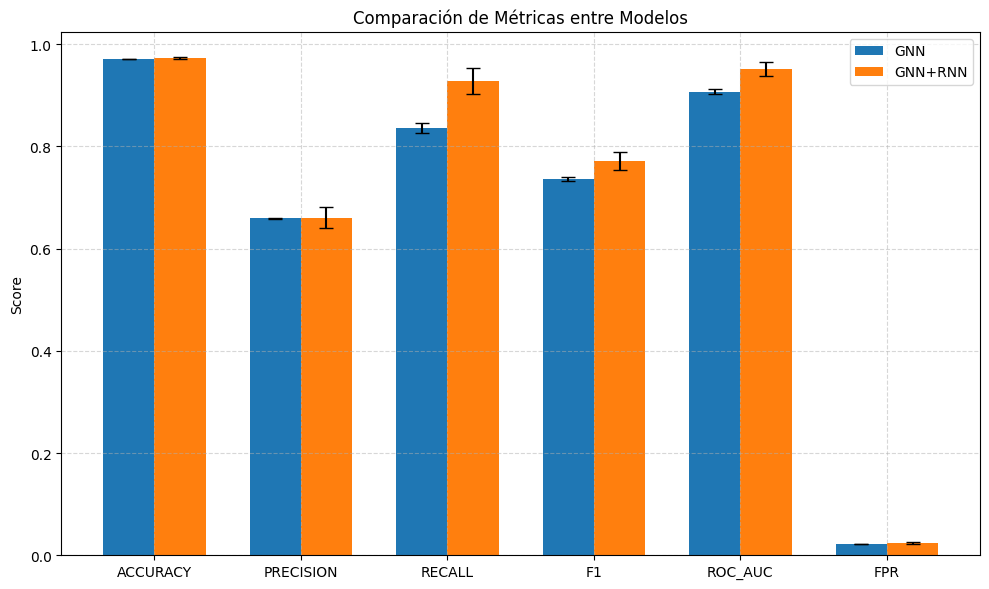

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'fpr']
labels = [m.upper() for m in metrics]
gnn_means = [np.mean(results_gnn[m]) for m in metrics]
gnn_stds = [np.std(results_gnn[m]) for m in metrics]
rnn_means = [np.mean(results_rnn[m]) for m in metrics]
rnn_stds = [np.std(results_rnn[m]) for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, gnn_means, width, yerr=gnn_stds, label='GNN', capsize=5)
rects2 = ax.bar(x + width/2, rnn_means, width, yerr=rnn_stds, label='GNN+RNN', capsize=5)

ax.set_ylabel('Score')
ax.set_title('Comparación de Métricas entre Modelos')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


/tmp/ipython-input-30-2972164549.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['GNN', 'GNN+RNN'], patch_artist=True)


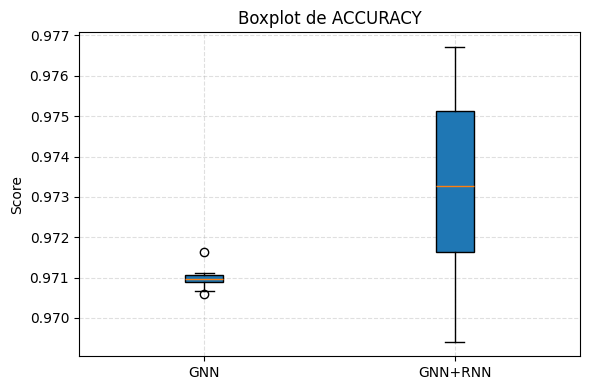

/tmp/ipython-input-30-2972164549.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['GNN', 'GNN+RNN'], patch_artist=True)


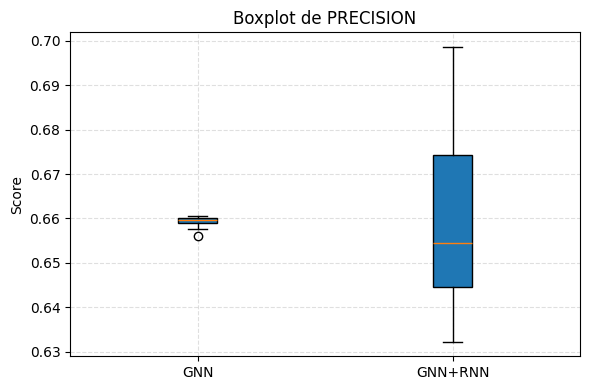

/tmp/ipython-input-30-2972164549.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['GNN', 'GNN+RNN'], patch_artist=True)


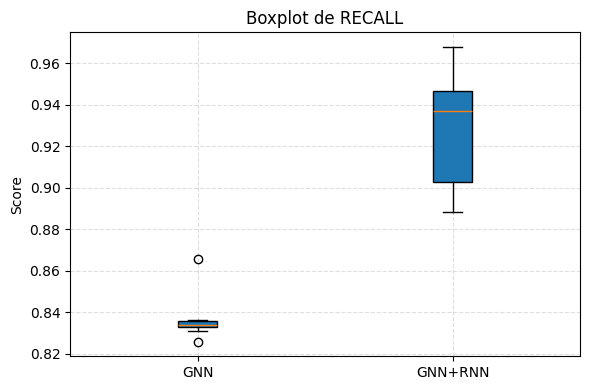

/tmp/ipython-input-30-2972164549.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['GNN', 'GNN+RNN'], patch_artist=True)


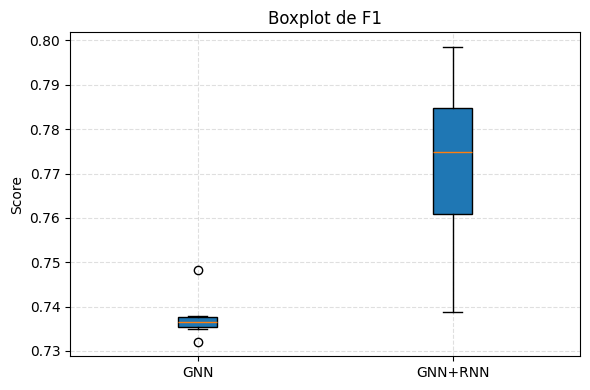

/tmp/ipython-input-30-2972164549.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['GNN', 'GNN+RNN'], patch_artist=True)


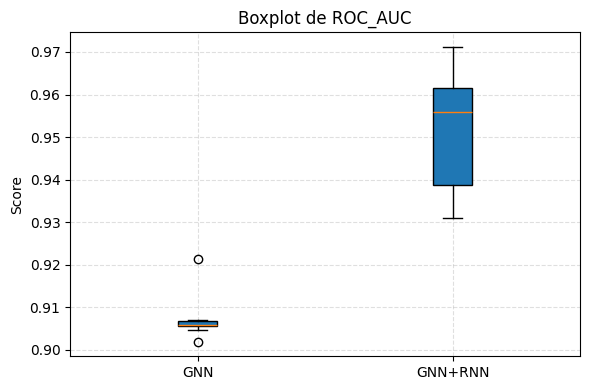

/tmp/ipython-input-30-2972164549.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['GNN', 'GNN+RNN'], patch_artist=True)


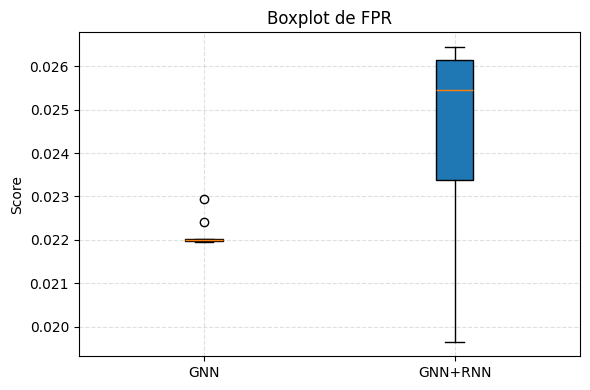

In [ ]:
import matplotlib.pyplot as plt

for metric in metrics:
    data = [results_gnn[metric], results_rnn[metric]]
    plt.figure(figsize=(6, 4))
    plt.boxplot(data, labels=['GNN', 'GNN+RNN'], patch_artist=True)
    plt.title(f'Boxplot de {metric.upper()}')
    plt.ylabel('Score')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()
